Step 1: Import Libraries with Additional Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from scipy import stats
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)      

Step2: Data Loading and Initial Exploration


Shape of below70_df: (174, 27)
Shape of checkin_df: (232, 9)
Missing values in below70_df:
 fullname_hash                        0
Time_taken_checkin                   0
Grade_checkin                        0
Time_taken_checkin(s)                0
start_time_norm_checkin              0
duration_norm_checkin                0
total_quiz_attempts_checkin          1
total_quiz_time_checkin              1
total_quiz_time_checkin_seconds      1
total_lecture_sessions_start        27
total_complete_sessions             27
lecture1_sessions_complete          27
lecture2_sessions_complete          27
total_lecture_time                  27
lecture1_time                       27
lecture2_time                       27
total_lecture_time_seconds          27
lecture1_time_seconds               27
lecture2_time_seconds               27
total_quiz_attempts_checkout        71
total_quiz_time_checkout            71
total_quiz_time_checkout_seconds    71
Time_taken_checkout                 69
Grade_check

<Figure size 1200x600 with 0 Axes>

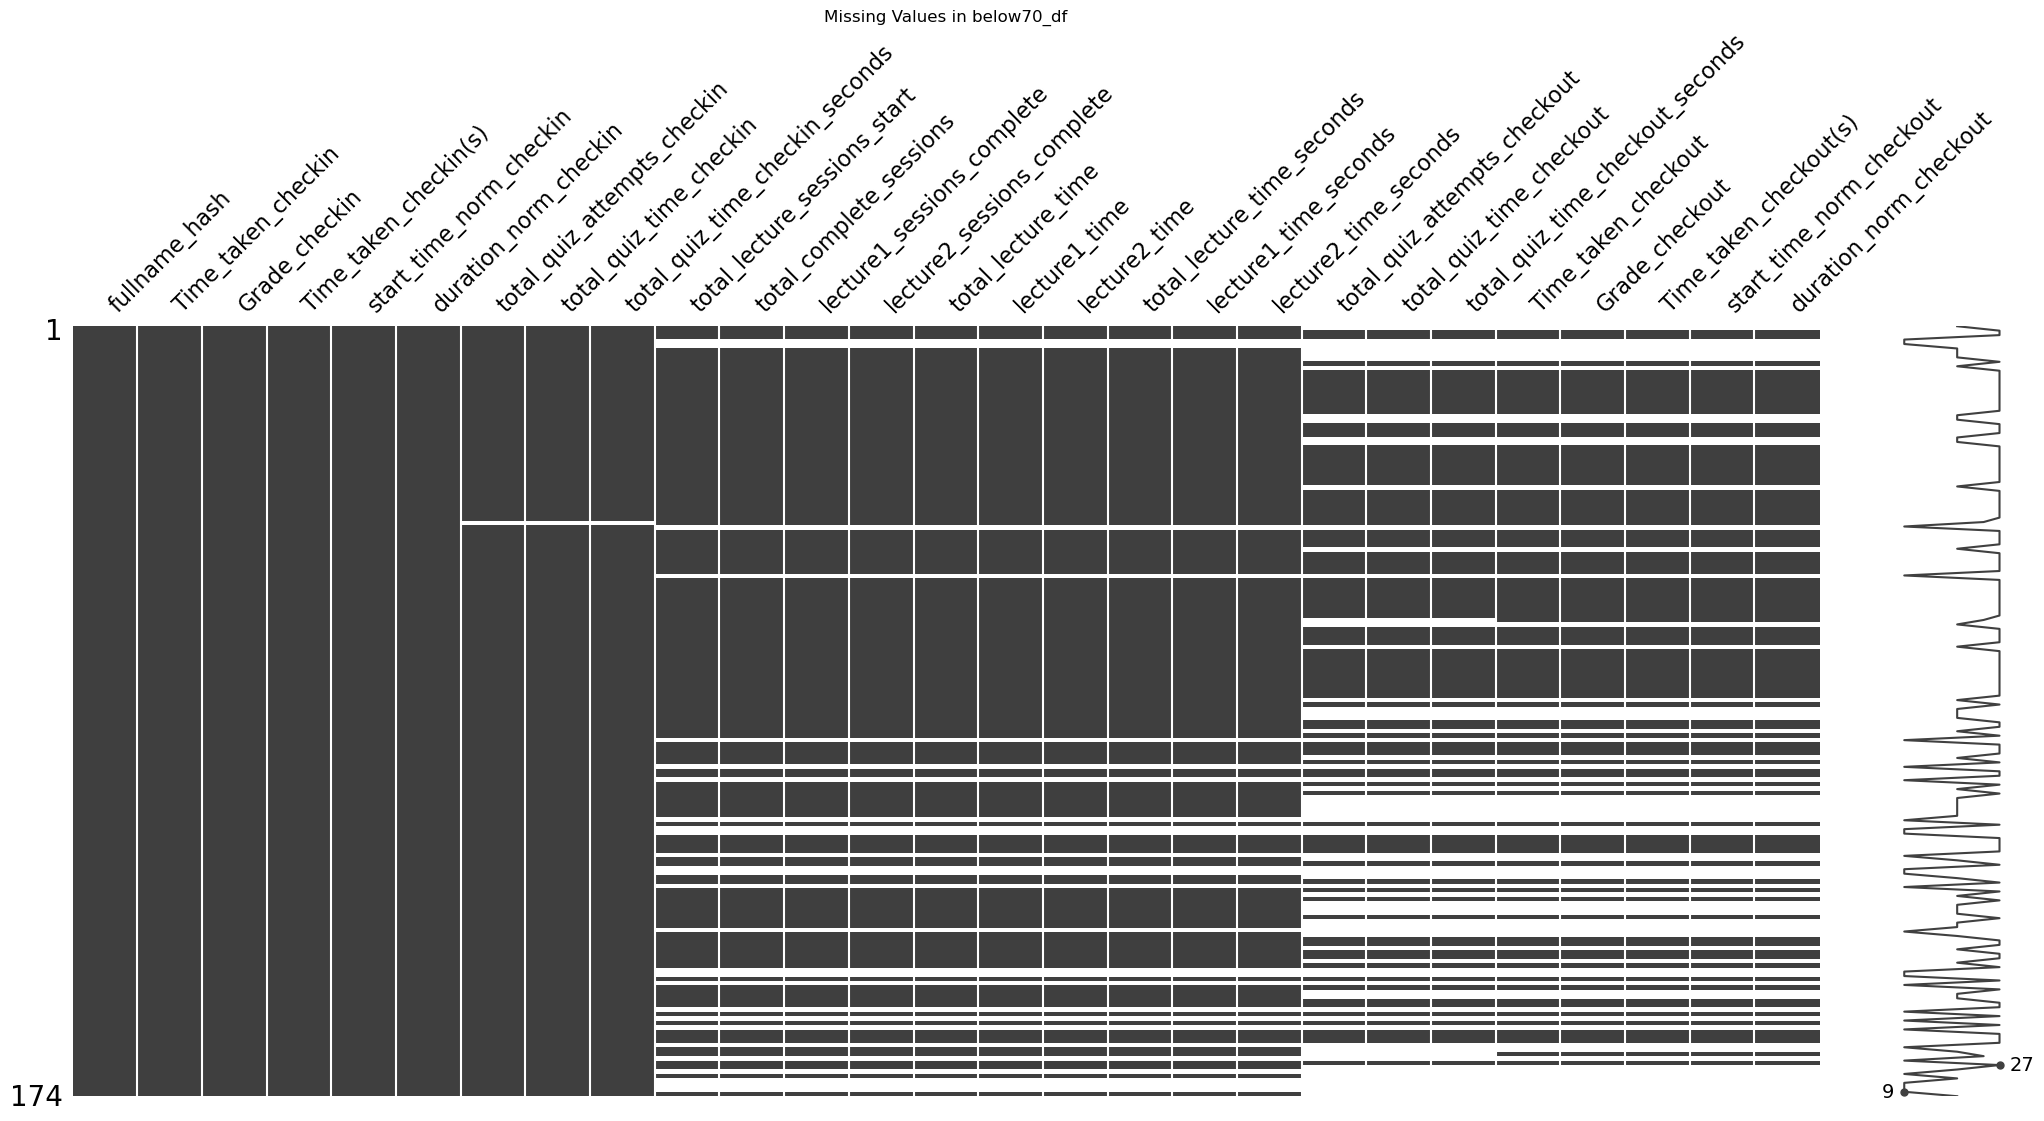

<Figure size 1200x600 with 0 Axes>

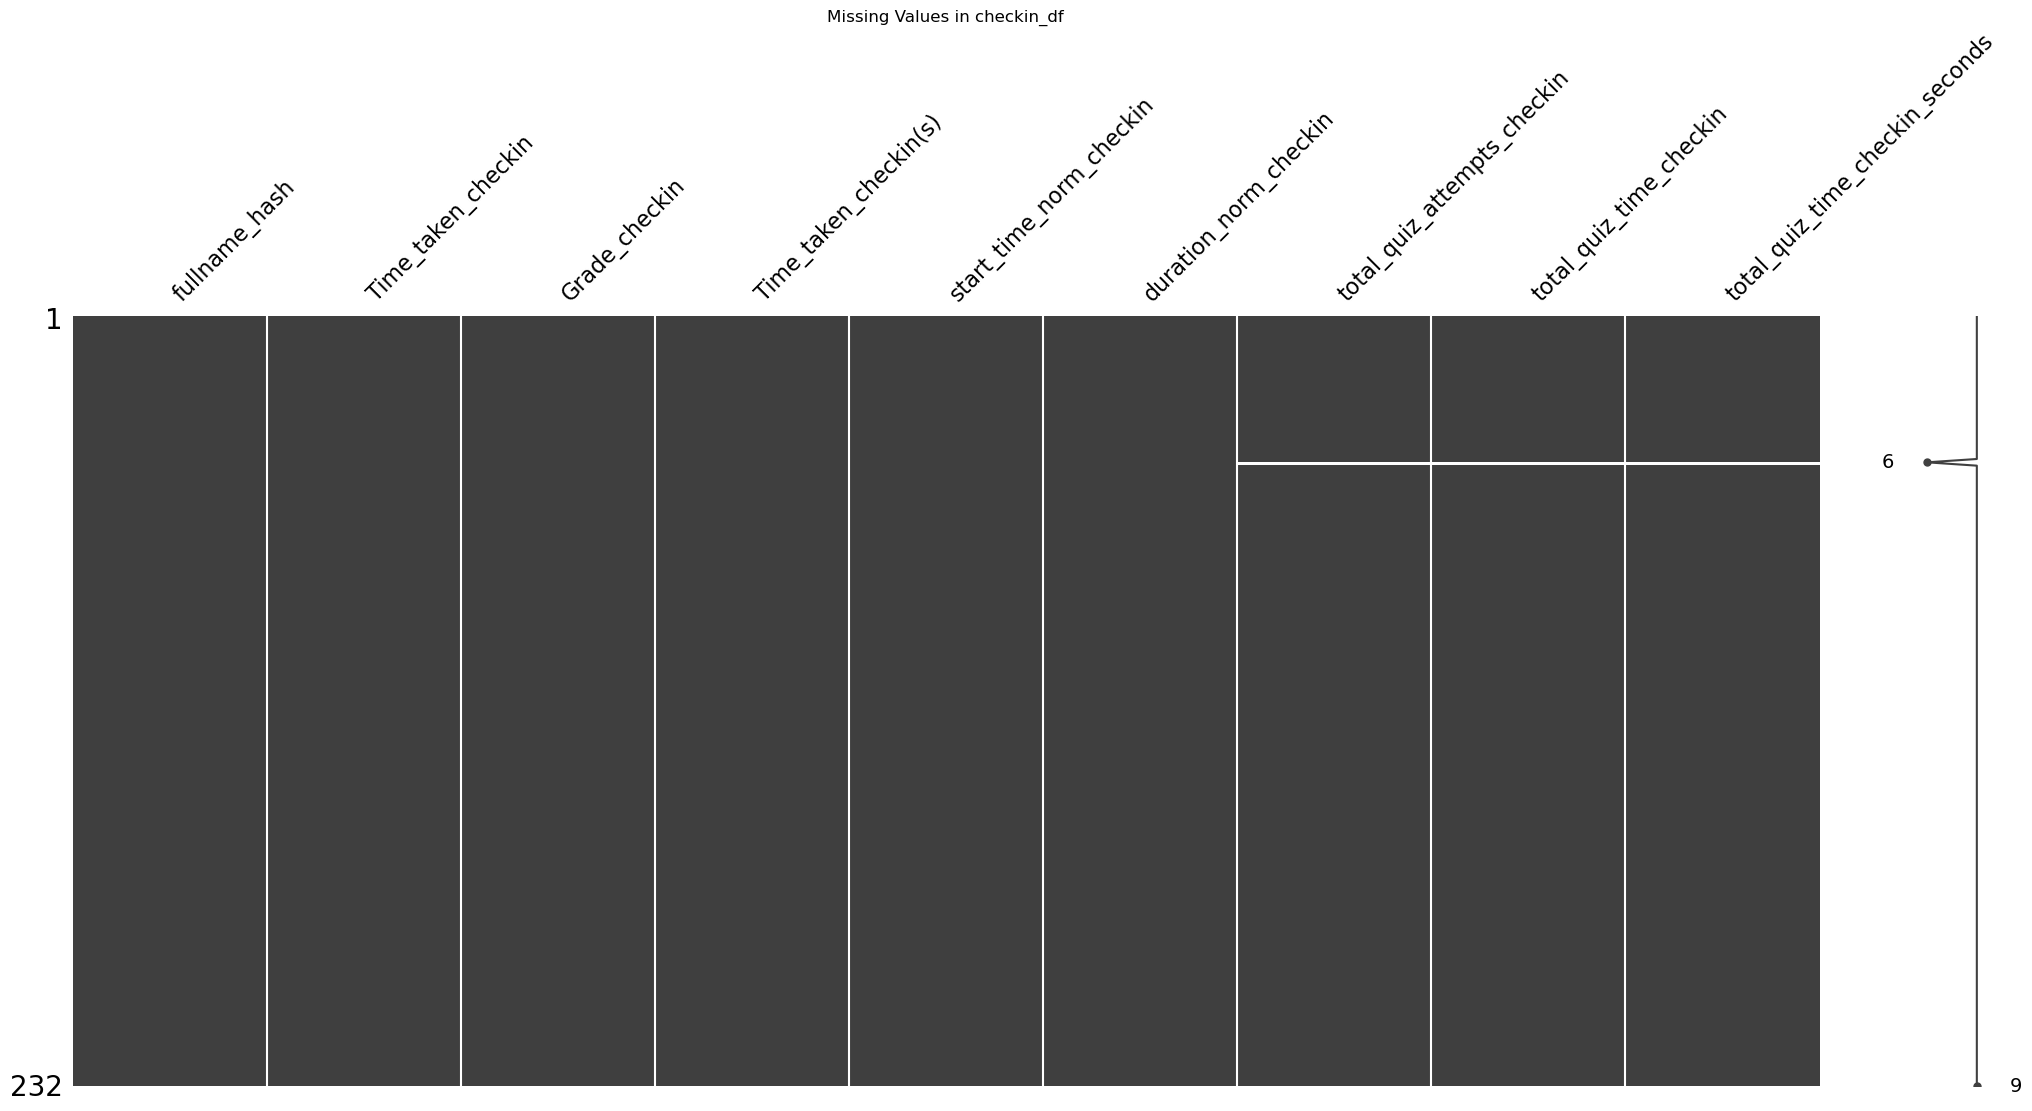

In [2]:
# Load the datasets
below70_df = pd.read_csv('student(below70)_final_datasets.csv')
checkin_df = pd.read_csv('all_students_checkin.csv')

# Check the shape of the datasets
print("Shape of below70_df:", below70_df.shape)
print("Shape of checkin_df:", checkin_df.shape)

# Check for missing values in the datasets
print("Missing values in below70_df:\n", below70_df.isnull().sum())
print("Missing values in checkin_df:\n", checkin_df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(12, 6))
msno.matrix(below70_df)
plt.title('Missing Values in below70_df')
plt.show()

plt.figure(figsize=(12, 6))
msno.matrix(checkin_df)
plt.title('Missing Values in checkin_df')
plt.show()

# Move targets to the end
below70_df = below70_df[[col for col in below70_df.columns if col != 'Grade_checkout'] + ['Grade_checkout']]
checkin_df = checkin_df[[col for col in checkin_df.columns if col != 'Grade_checkin'] + ['Grade_checkin']]

# Drop missing values
below70_df = below70_df.dropna()
checkin_df = checkin_df.dropna()

Step3: Enhanced Feature Engineering


Created advanced features for below70 dataset
New shape: (102, 23)
Created advanced features for checkin dataset
New shape: (231, 9)

Generating Correlation Matrices After Feature Engineering:


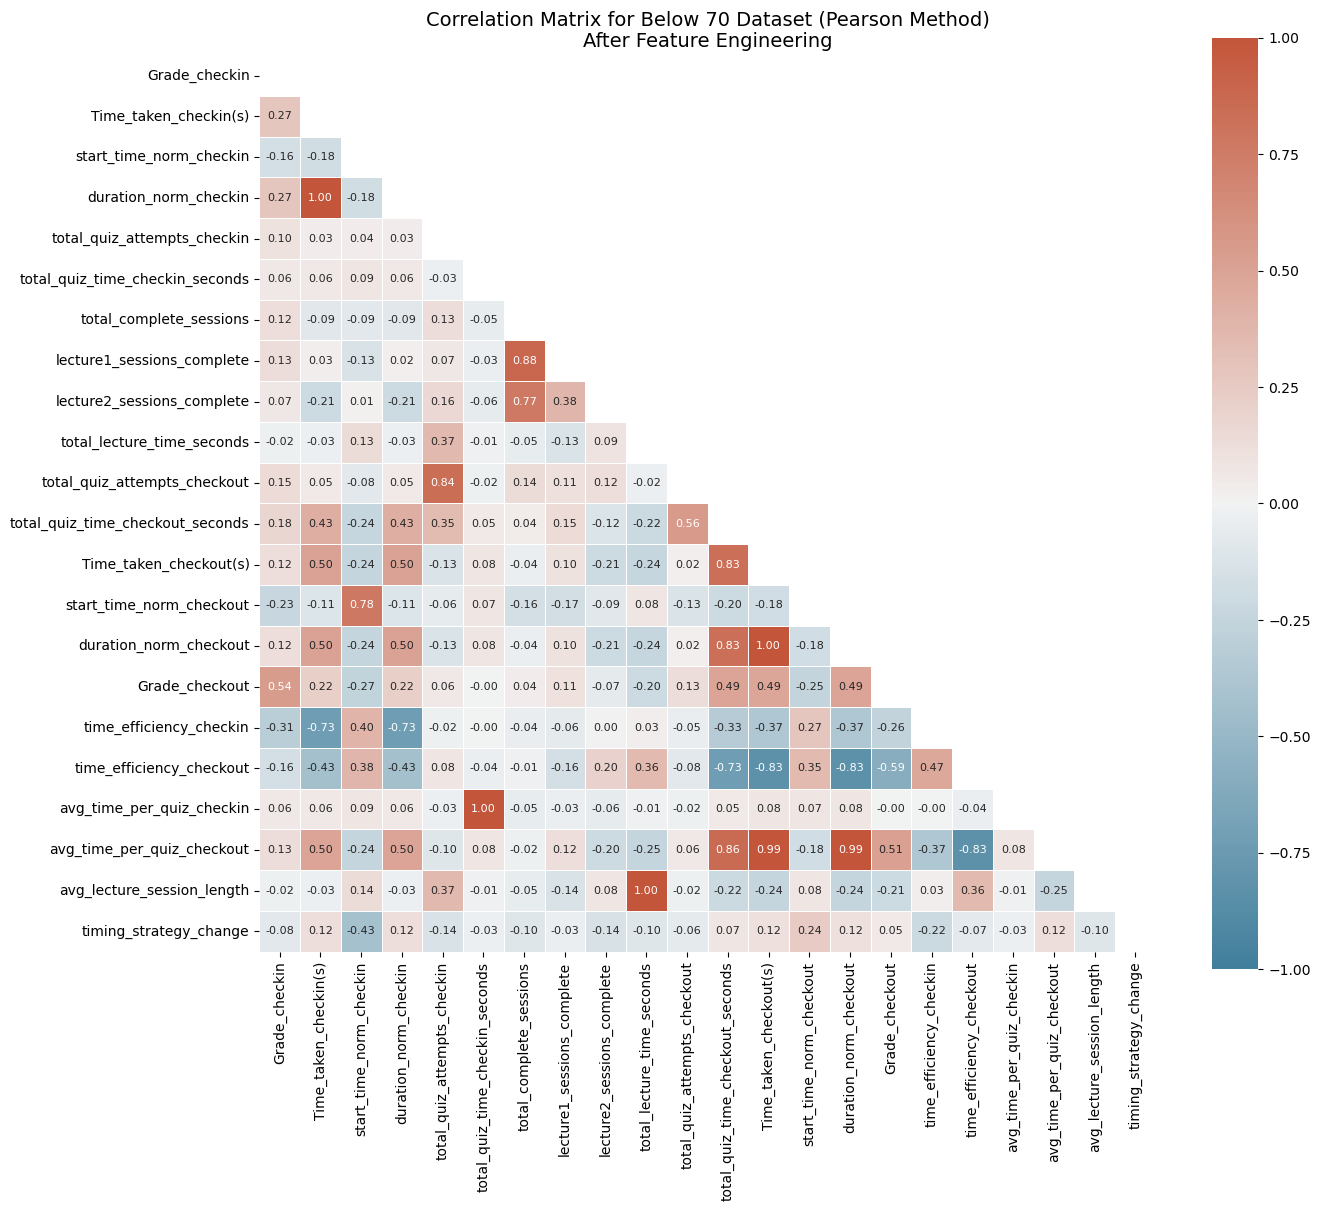

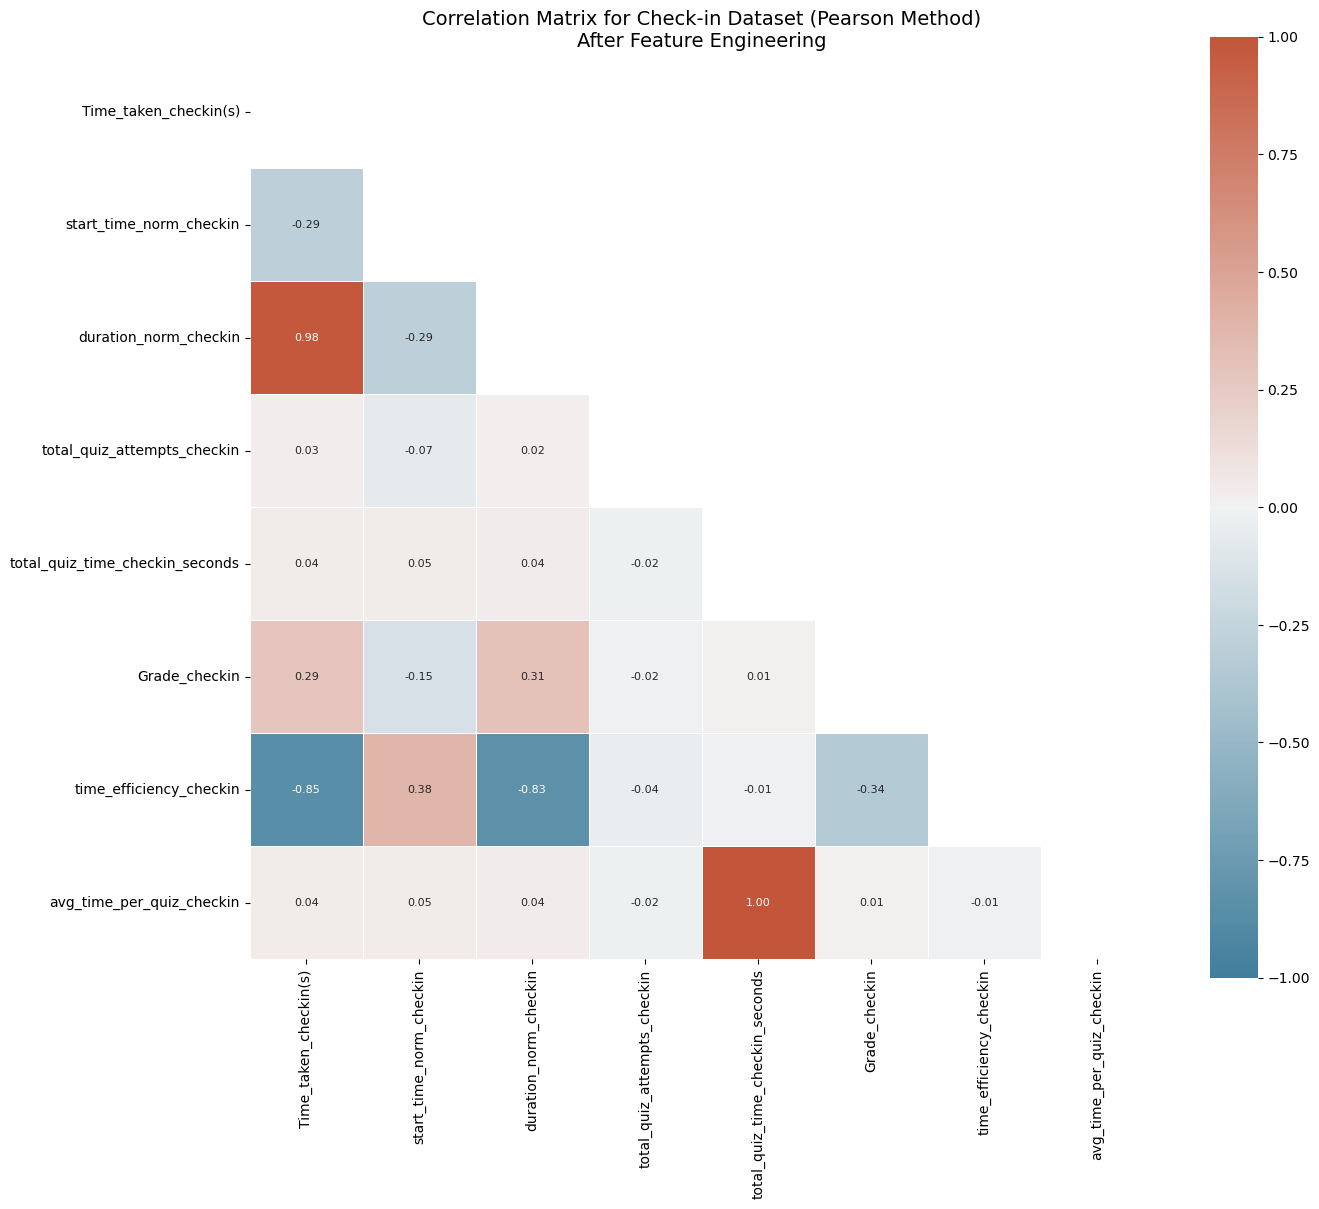

In [3]:
def create_advanced_features(df, dataset_name):
    """
    Create advanced features based on domain knowledge and exploratory analysis
    """
    df = df.copy()
    
    # Convert fullname_hash to categorical to keep but not use in models
    df['fullname_hash'] = df['fullname_hash'].astype('category')
    
    # Drop redundant columns
    if dataset_name == 'below70':
        columns_to_drop = [
            'Time_taken_checkin',
            'total_quiz_time_checkin', 
            'total_lecture_time',
            'total_quiz_time_checkout',
            'Time_taken_checkout',
            'lecture1_sessions_complete'
            'lecture2_sessions_complete',
            'lecture1_time',
            'lecture2_time',
            'lecture1_time_seconds',
            'lecture2_time_seconds',
            'total_lecture_sessions_start'


        ]
    else:  # chceckin_df
        columns_to_drop = [
            'Time_taken_checkin',
            'total_quiz_time_checkin'
        ]
    
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    
    # 1. Efficiency metrics
    if all(col in df.columns for col in ['start_time_norm_checkin', 'duration_norm_checkin']):
        df['time_efficiency_checkin'] = df['start_time_norm_checkin'] / df['duration_norm_checkin'].clip(lower=0.1)
    
    if all(col in df.columns for col in ['start_time_norm_checkout', 'duration_norm_checkout']):
        df['time_efficiency_checkout'] = df['start_time_norm_checkout'] / df['duration_norm_checkout'].clip(lower=0.1)
    
    # 2. Quiz performance metrics
    if all(col in df.columns for col in ['total_quiz_time_checkin_seconds', 'total_quiz_attempts_checkin']):
        df['avg_time_per_quiz_checkin'] = df['total_quiz_time_checkin_seconds'] / df['total_quiz_attempts_checkin'].clip(lower=1)
    
    if all(col in df.columns for col in ['total_quiz_time_checkout_seconds', 'total_quiz_attempts_checkout']):
        df['avg_time_per_quiz_checkout'] = df['total_quiz_time_checkout_seconds'] / df['total_quiz_attempts_checkout'].clip(lower=1)
    
    # 3. Study pattern features
    if all(col in df.columns for col in ['total_complete_sessions', 'total_lecture_time_seconds']):
        df['avg_lecture_session_length'] = df['total_lecture_time_seconds'] / df['total_complete_sessions'].clip(lower=1)

    # 4. Timing strategy features (when they start relative to duration)
    if all(col in df.columns for col in ['start_time_norm_checkin', 'start_time_norm_checkout']):
        df['timing_strategy_change'] = df['start_time_norm_checkout'] - df['start_time_norm_checkin']
    
    # 5. Grade improvement potential (for below80 dataset only)
    if dataset_name == 'below80' and all(col in df.columns for col in ['Grade_checkin', 'Grade_checkout']):
        df['grade_improvement_potential'] = 100 - df['Grade_checkin']
        df['actual_grade_improvement'] = df['Grade_checkout'] - df['Grade_checkin']
        df['improvement_efficiency'] = df['actual_grade_improvement'] / df['grade_improvement_potential'].clip(lower=0.1)
    
    print(f"Created advanced features for {dataset_name} dataset")
    print(f"New shape: {df.shape}")
    
    return df

# Apply feature engineering
below70_df = create_advanced_features(below70_df, 'below70')
checkin_df = create_advanced_features(checkin_df, 'checkin')



# Add to the end of Step3: Enhanced Feature Engineering

def plot_correlation_matrix(df, dataset_name, method='pearson'):
    """
    Create and visualize correlation matrix for dataset after feature engineering
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe with all features including engineered ones
    dataset_name : str
        Name of the dataset for the plot title
    method : str, default='pearson'
        Correlation method ('pearson', 'spearman', or 'kendall')
    """
    # Get numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Calculate correlation matrix
    correlation_matrix = numeric_df.corr(method=method)
    
    # Set up the matplotlib figure
    plt.figure(figsize=(14, 12))
    
    # Draw the heatmap with a color bar
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    sns.heatmap(
        correlation_matrix, 
        annot=True, 
        mask=mask,
        cmap=cmap,
        vmax=1.0, 
        vmin=-1.0, 
        center=0,
        square=True, 
        linewidths=.5, 
        fmt='.2f',
        annot_kws={"size": 8}
    )
    
    plt.title(f'Correlation Matrix for {dataset_name} Dataset ({method.capitalize()} Method)\nAfter Feature Engineering', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot correlation matrices using different methods
print("\nGenerating Correlation Matrices After Feature Engineering:")

# Pearson (linear correlation)
plot_correlation_matrix(below70_df, "Below 70", method='pearson')
plot_correlation_matrix(checkin_df, "Check-in", method='pearson')




Step4: Advanced Outlier Detection and Handling


------------------------------------------------------------
Outlier Detection Comparison for Below 70 Dataset
------------------------------------------------------------

WINSORIZE Method:
Total outliers detected: 156
Percentage of data points identified as outliers: 7.28%
Top 5 features with most outliers:
  - total_quiz_time_checkin_seconds: 12 outliers (11.76% of values)
  - total_lecture_time_seconds: 12 outliers (11.76% of values)
  - time_efficiency_checkin: 12 outliers (11.76% of values)
  - time_efficiency_checkout: 12 outliers (11.76% of values)
  - avg_lecture_session_length: 12 outliers (11.76% of values)

IQR Method:
Total outliers detected: 135
Percentage of data points identified as outliers: 6.30%
Top 5 features with most outliers:
  - total_quiz_time_checkin_seconds: 18 outliers (17.65% of values)
  - total_lecture_time_seconds: 16 outliers (15.69% of values)
  - time_efficiency_checkout: 13 outliers (12.75% of values)
  - avg_lecture_session_length: 13 outliers (12.

/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/3432535775.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Outlier Percentage', data=comparison_df, palette='viridis')


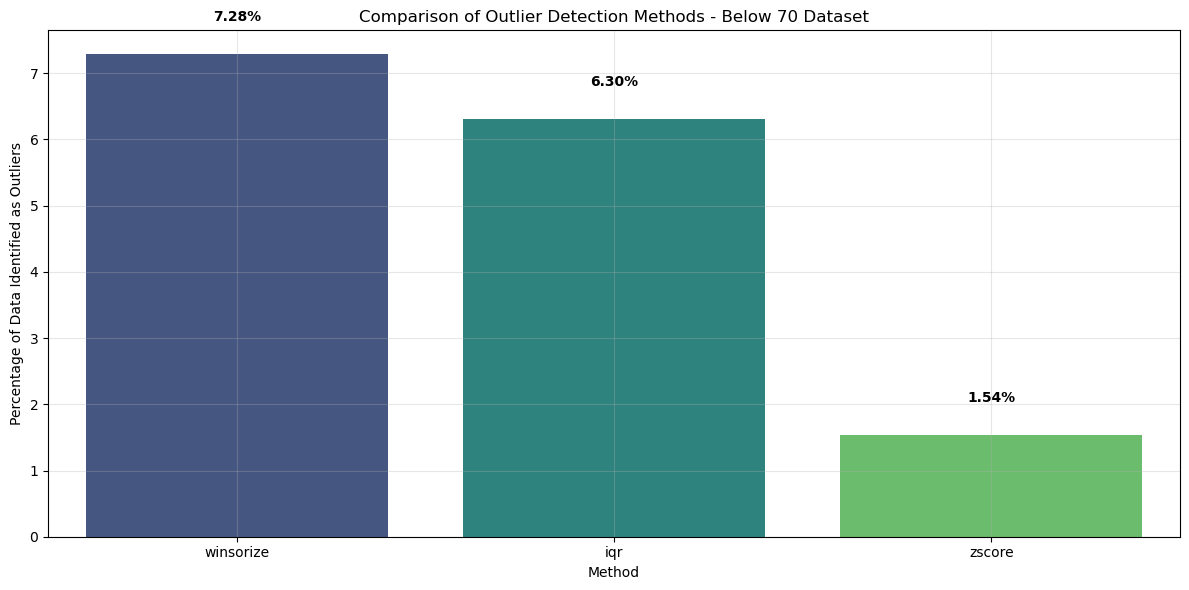


------------------------------------------------------------
Outlier Detection Comparison for Check-in Dataset
------------------------------------------------------------

WINSORIZE Method:
Total outliers detected: 114
Percentage of data points identified as outliers: 7.05%
Top 5 features with most outliers:
  - start_time_norm_checkin: 24 outliers (10.39% of values)
  - total_quiz_time_checkin_seconds: 24 outliers (10.39% of values)
  - time_efficiency_checkin: 24 outliers (10.39% of values)
  - avg_time_per_quiz_checkin: 17 outliers (7.36% of values)
  - Time_taken_checkin(s): 13 outliers (5.63% of values)

IQR Method:
Total outliers detected: 136
Percentage of data points identified as outliers: 8.41%
Top 5 features with most outliers:
  - total_quiz_time_checkin_seconds: 30 outliers (12.99% of values)
  - time_efficiency_checkin: 26 outliers (11.26% of values)
  - duration_norm_checkin: 19 outliers (8.23% of values)
  - Time_taken_checkin(s): 18 outliers (7.79% of values)
  - avg

/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/3432535775.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Outlier Percentage', data=comparison_df, palette='viridis')


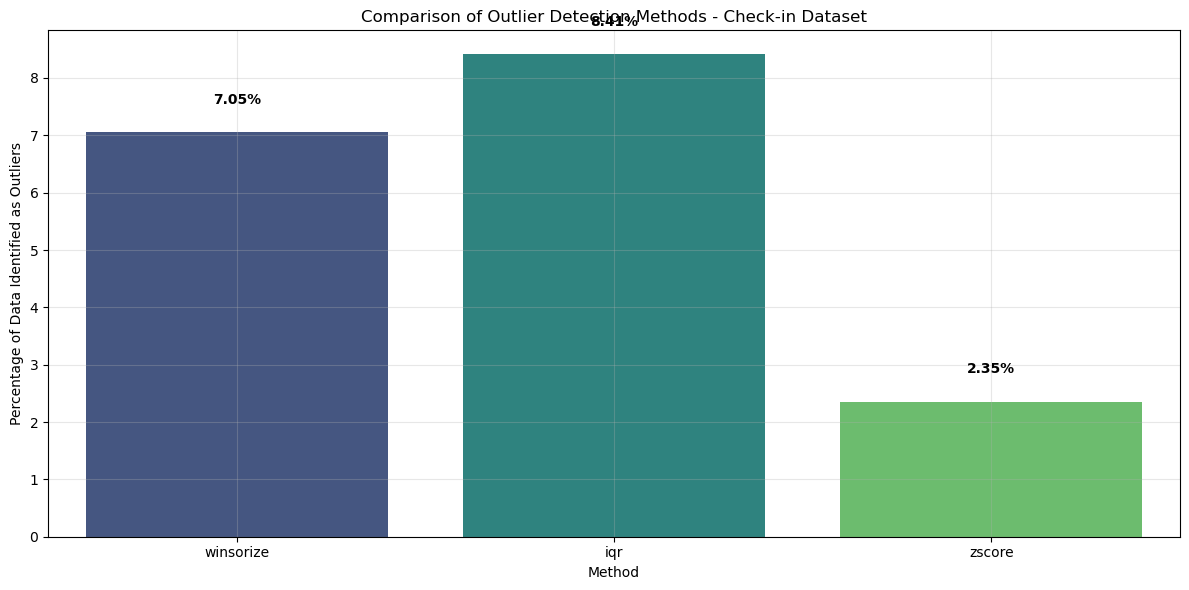


Visualizing the effect of outlier handling methods...


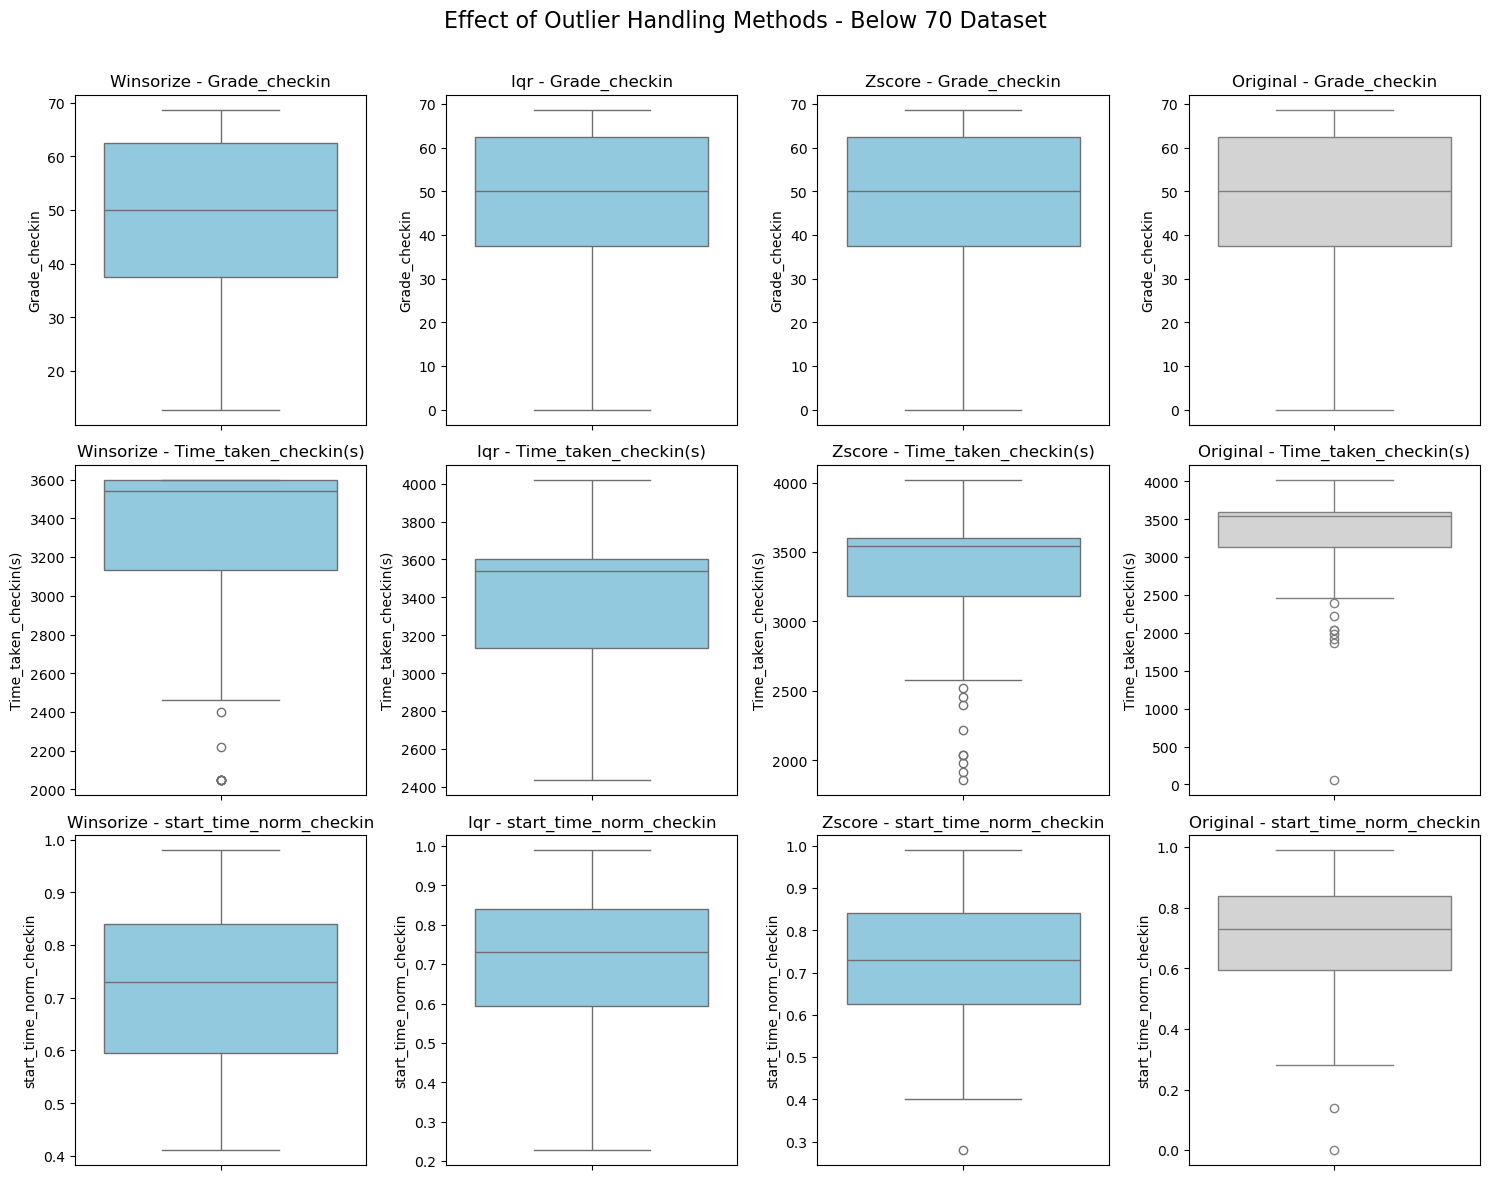

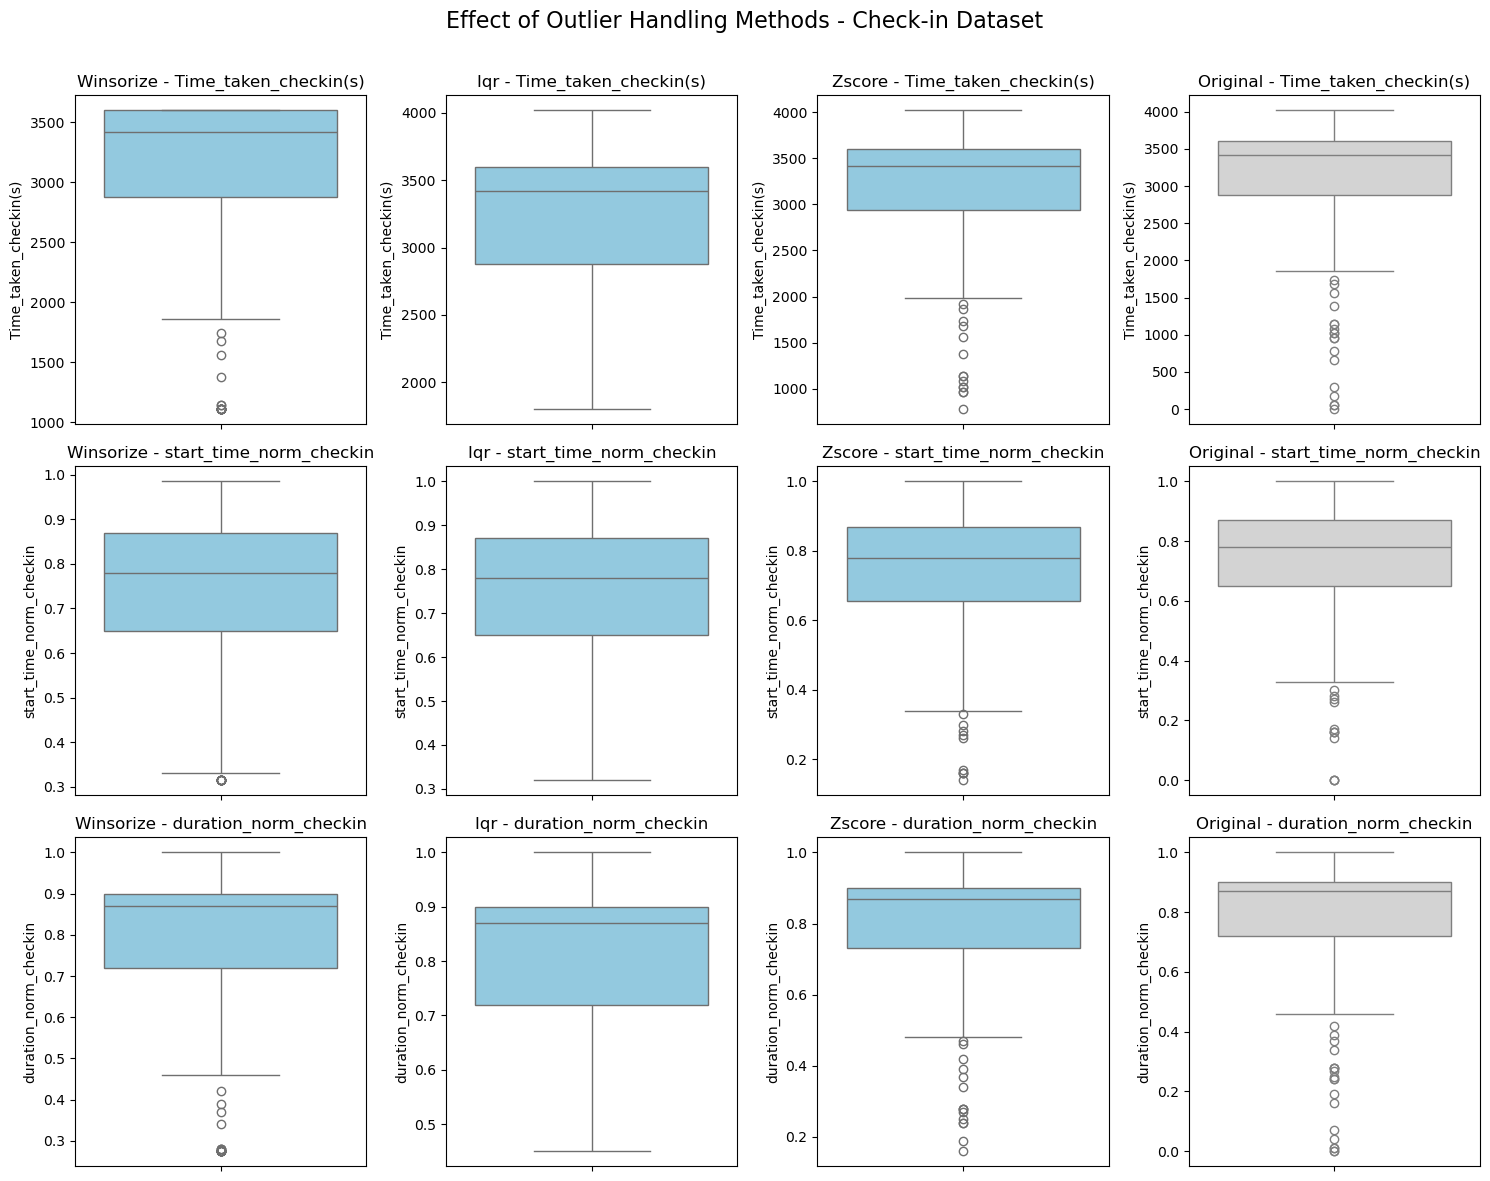


Applying the recommended outlier handling method (winsorize)...


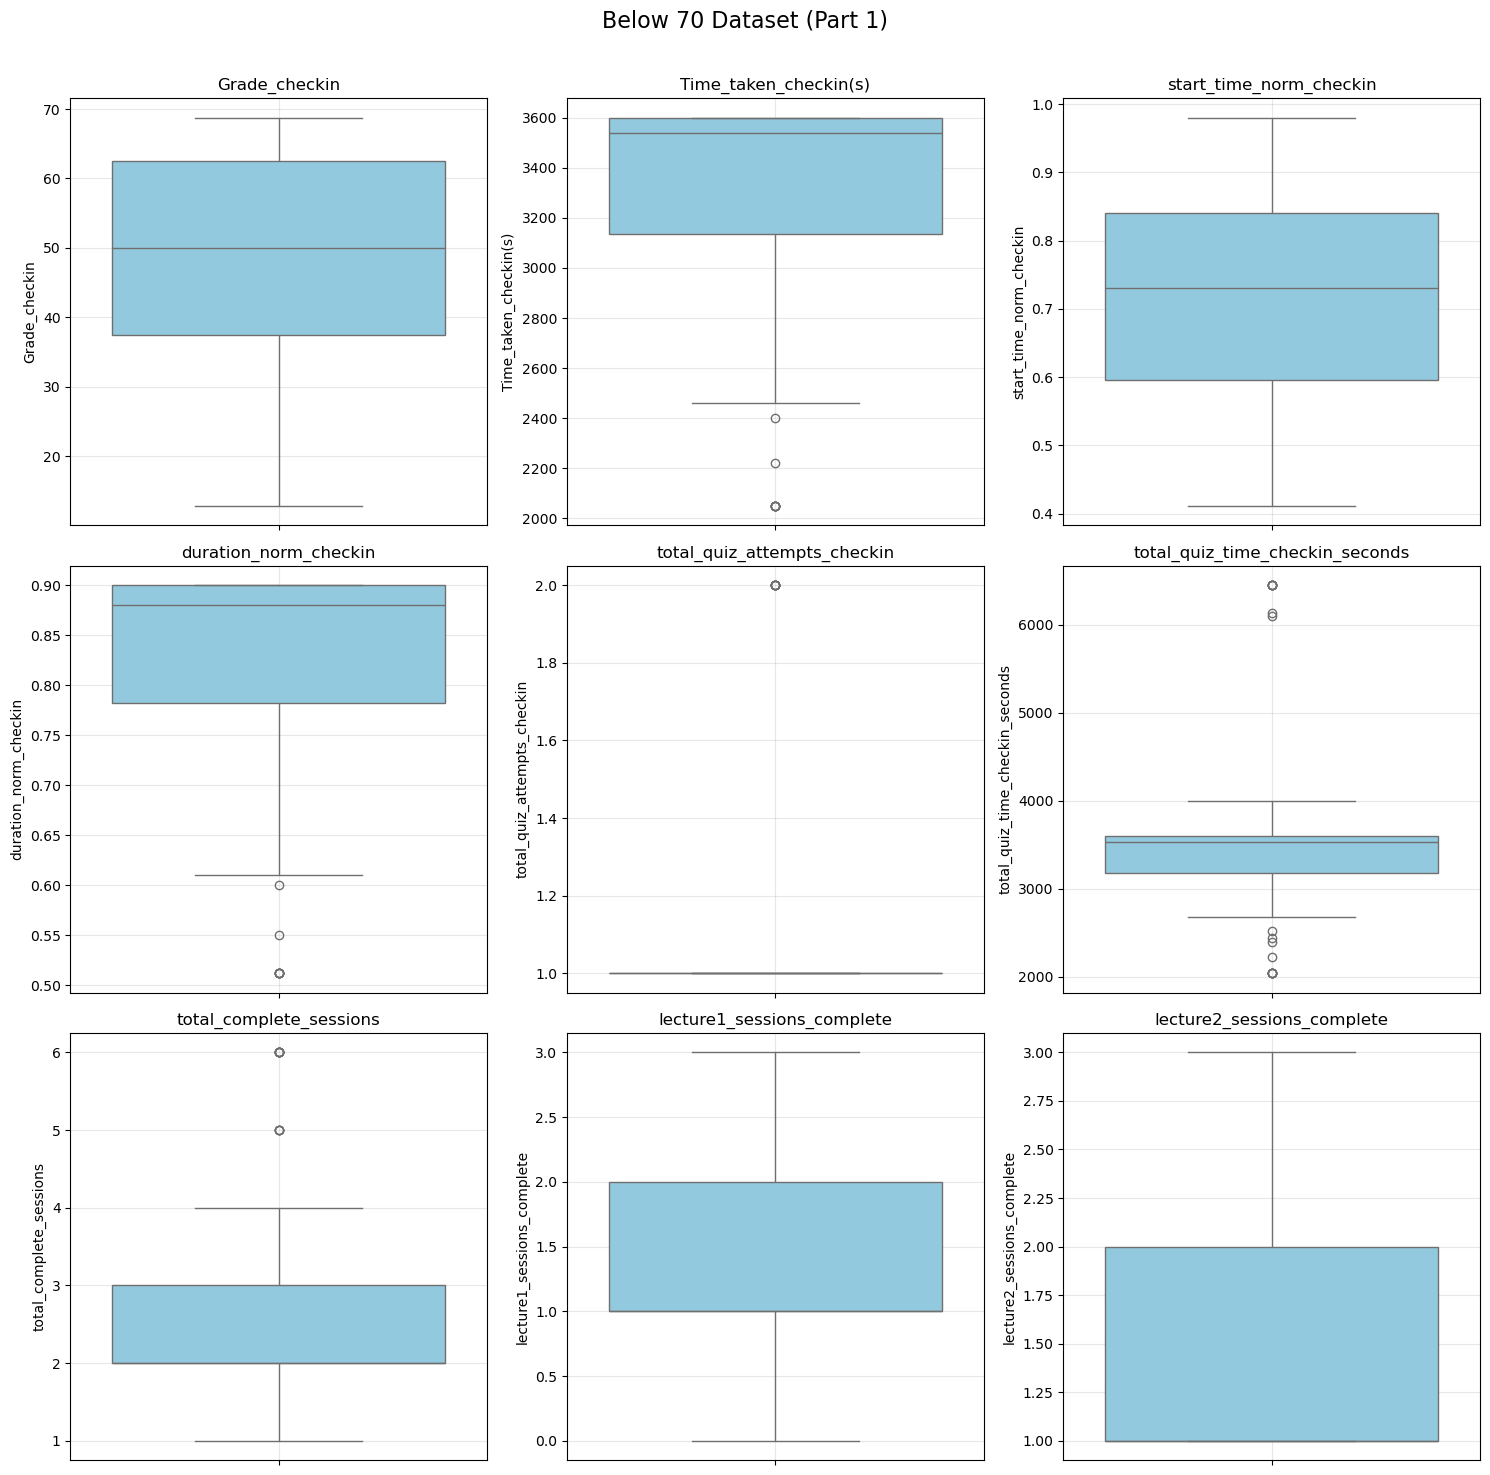

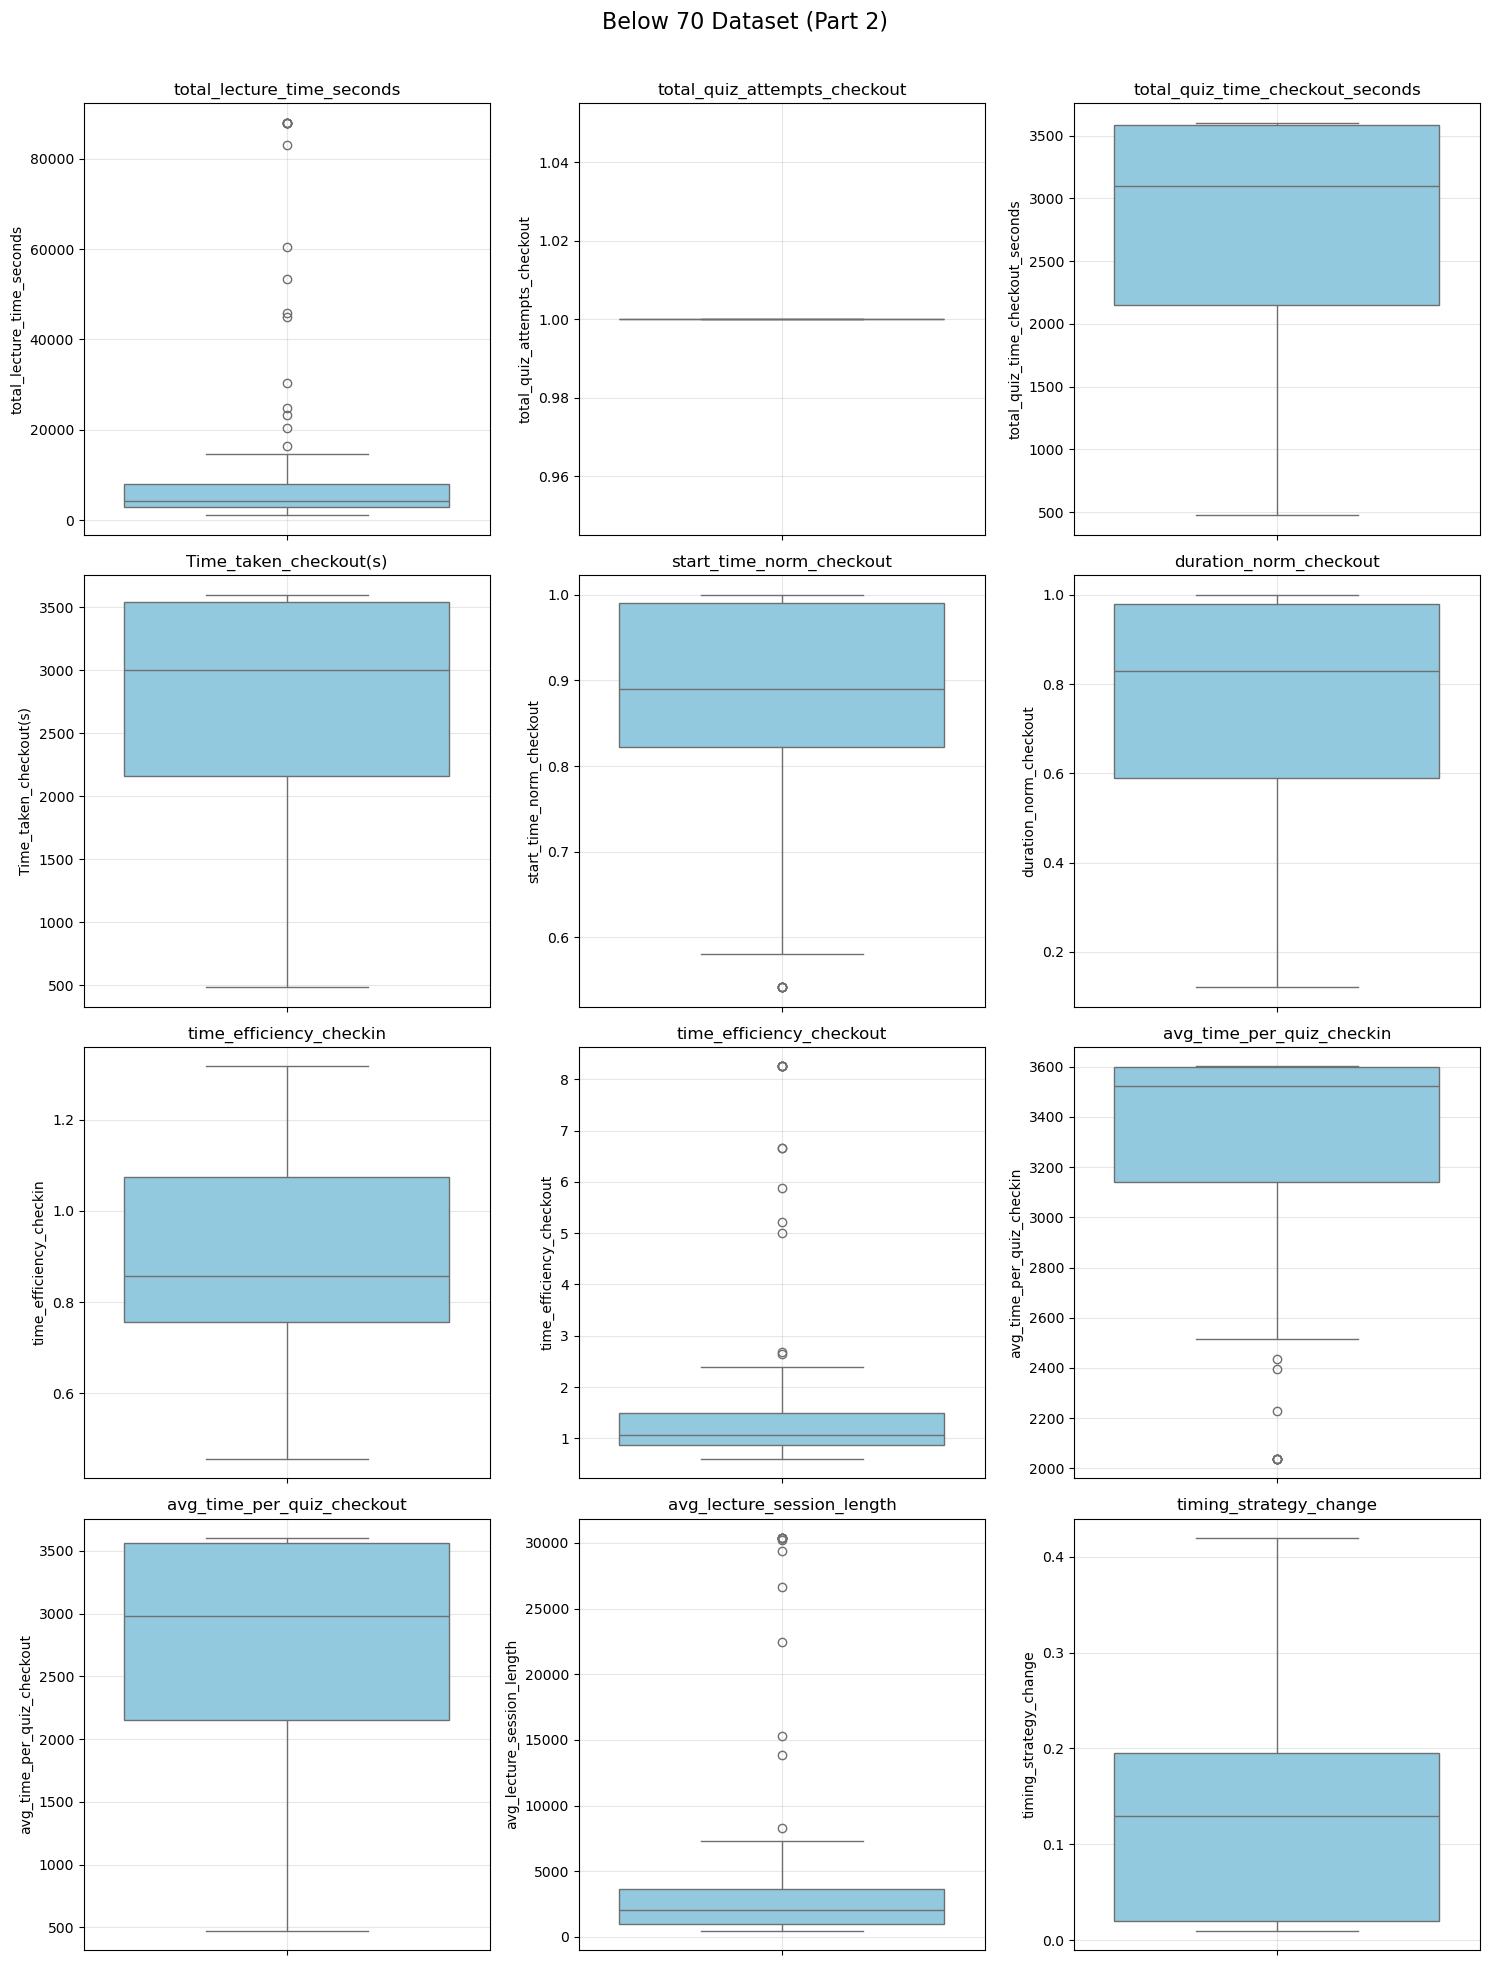

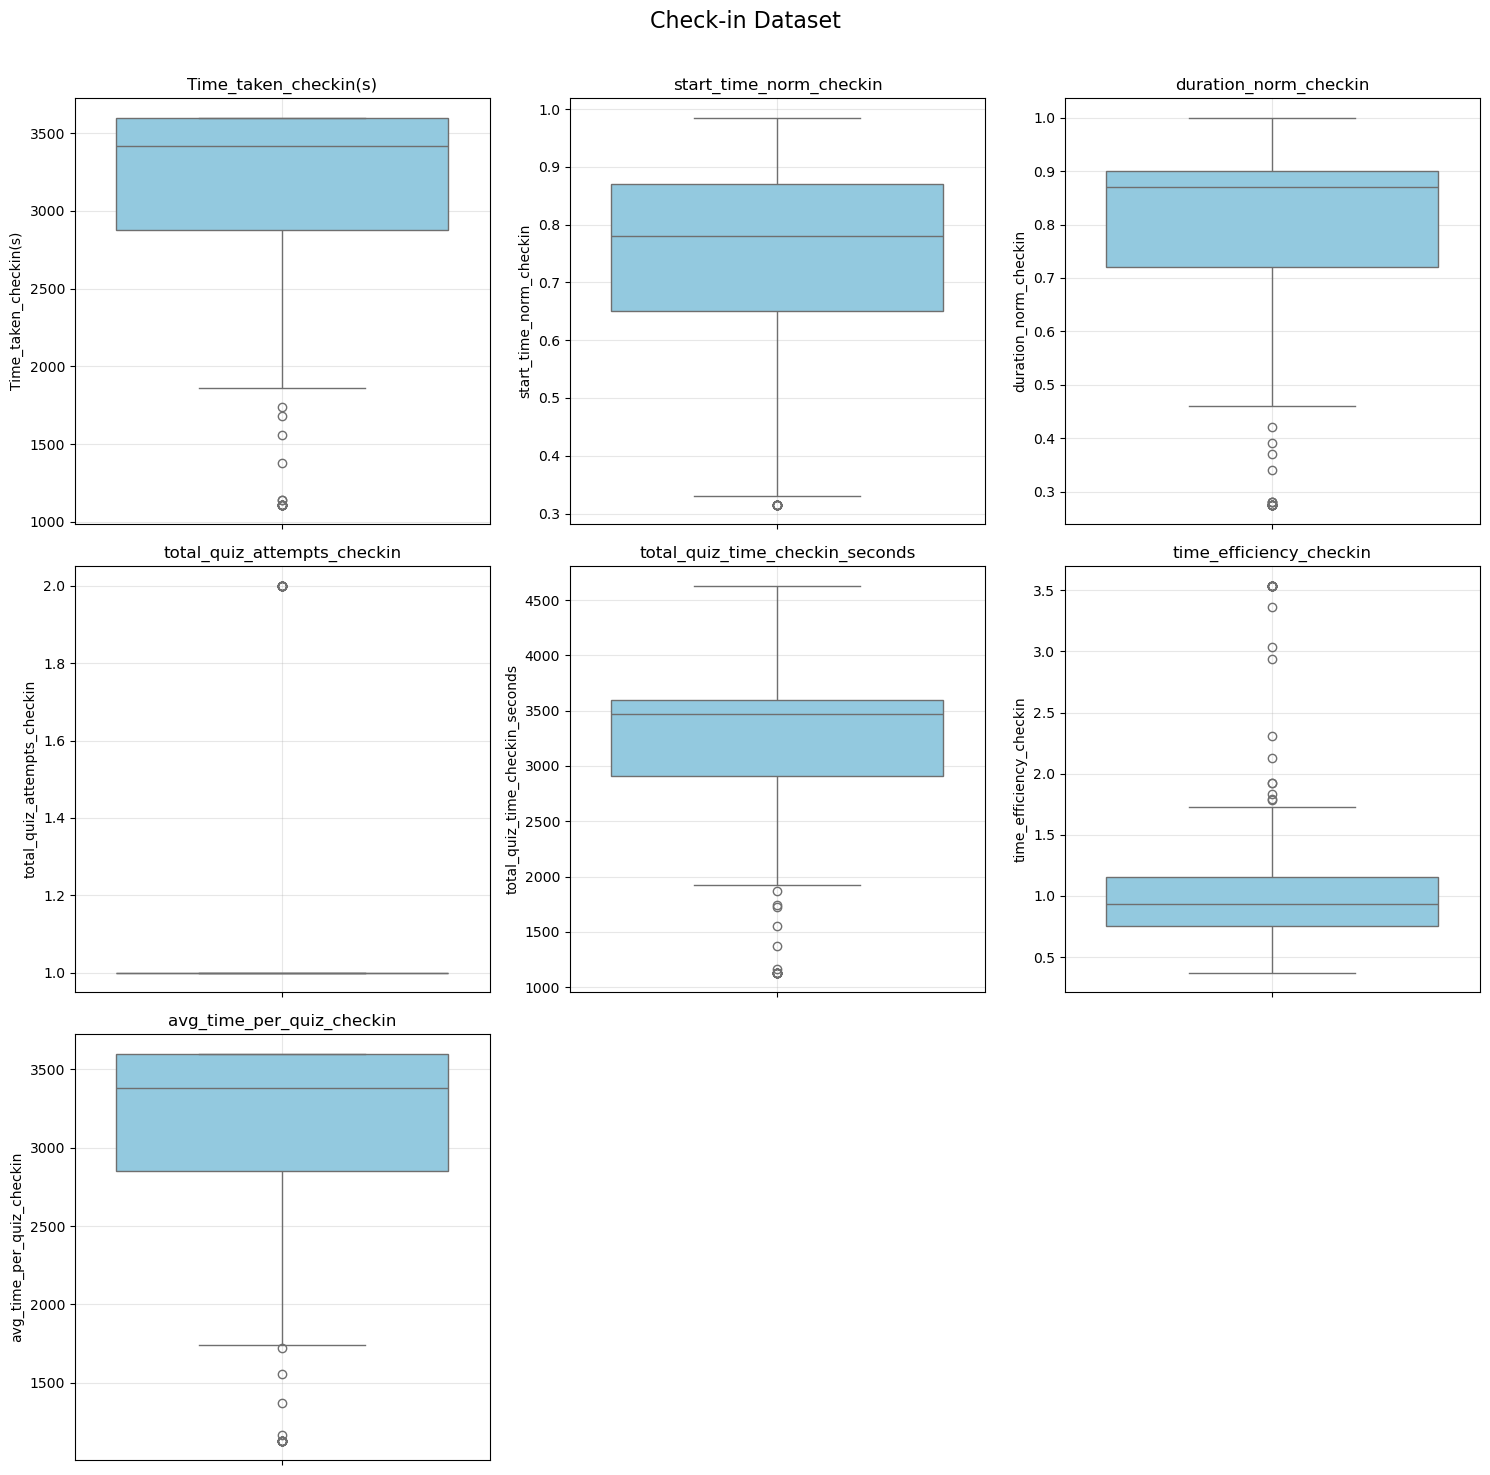


OUTLIER HANDLING METHOD ANALYSIS AND RECOMMENDATION

Based on the outlier detection and handling comparison:

1. WINSORIZE METHOD:
   - Identifies a moderate number of outliers (10% by design - 5% on each tail)
   - Preserves the distribution shape while capping extreme values
   - Less aggressive than other methods, minimizing information loss
   - Replaces extreme values with less extreme percentile values rather than removing them

2. IQR METHOD:
   - More sensitive to outliers in non-normal distributions
   - Can be too aggressive for some features, especially those with natural skewness
   - May identify legitimate but unusual values as outliers
   - Works well for normally distributed data but can struggle with skewed distributions

3. Z-SCORE METHOD:
   - Assumes normal distribution (which may not be true for all features)
   - Uses fixed threshold (±3 standard deviations)
   - Can be too lenient or too strict depending on the actual data distribution
   - Performs poorly on hi

In [4]:
def detect_outliers(df, numeric_cols, method):
    """
    Detect outliers using different methods and return outlier counts
    """
    outlier_counts = {}
    total_outliers = 0
    
    for col in numeric_cols:
        if method == 'winsorize':
            # Winsorize method (5th and 95th percentiles)
            lower_bound = np.percentile(df[col], 5)
            upper_bound = np.percentile(df[col], 95)
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            
        elif method == 'iqr':
            # IQR method
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            
        elif method == 'zscore':
            # Z-score method
            z_scores = stats.zscore(df[col])
            abs_z_scores = np.abs(z_scores)
            outliers = df[abs_z_scores >= 3]  # Values beyond 3 standard deviations
        
        outlier_counts[col] = len(outliers)
        total_outliers += len(outliers)
    
    return outlier_counts, total_outliers

def compare_outlier_methods(df, numeric_cols, dataset_name):
    """
    Compare different outlier detection methods
    """
    methods = ['winsorize', 'iqr', 'zscore']
    results = {}
    
    print(f"\n{'-'*60}")
    print(f"Outlier Detection Comparison for {dataset_name}")
    print(f"{'-'*60}")
    
    # Detect outliers with each method
    for method in methods:
        outlier_counts, total = detect_outliers(df, numeric_cols, method)
        results[method] = {
            'counts': outlier_counts,
            'total': total,
            'percentage': (total / (len(df) * len(numeric_cols))) * 100
        }
        
        print(f"\n{method.upper()} Method:")
        print(f"Total outliers detected: {total}")
        print(f"Percentage of data points identified as outliers: {results[method]['percentage']:.2f}%")
        
        # Show top 5 features with most outliers
        top_features = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        print("Top 5 features with most outliers:")
        for feature, count in top_features:
            print(f"  - {feature}: {count} outliers ({count/len(df)*100:.2f}% of values)")
    
    # Create a dataframe for plotting comparison
    comparison_df = pd.DataFrame({
        'Method': methods,
        'Total Outliers': [results[m]['total'] for m in methods],
        'Outlier Percentage': [results[m]['percentage'] for m in methods]
    })
    
    # Create bar plot comparing methods
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Method', y='Outlier Percentage', data=comparison_df, palette='viridis')
    plt.title(f'Comparison of Outlier Detection Methods - {dataset_name}')
    plt.ylabel('Percentage of Data Identified as Outliers')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=0)
    
    # Add value labels on bars
    for i, v in enumerate(comparison_df['Outlier Percentage']):
        plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Process data with each method and return handled datasets
    handled_dfs = {}
    for method in methods:
        handled_dfs[method] = handle_outliers(df, numeric_cols, method)
    
    return handled_dfs, results

def handle_outliers(df, numeric_cols, method='winsorize'):
    """
    Handle outliers using various methods:
    - winsorize: Cap outliers at percentile thresholds
    - iqr: Use IQR method to detect and cap outliers
    - zscore: Use Z-score to detect and cap outliers
    """
    df = df.copy()
    
    for col in numeric_cols:
        if method == 'winsorize':
            # Winsorize at 5th and 95th percentiles
            lower_bound = np.percentile(df[col], 5)
            upper_bound = np.percentile(df[col], 95)
            df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
            
        elif method == 'iqr':
            # IQR method
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
            
        elif method == 'zscore':
            # Z-score method
            z_scores = stats.zscore(df[col])
            abs_z_scores = np.abs(z_scores)
            filtered_entries = (abs_z_scores < 3)  # Keep only values within 3 standard deviations
            df.loc[~filtered_entries, col] = df[col].median()
    
    return df

def visualize_outlier_effects(original_df, handled_dfs, features, dataset_name):
    """
    Visualize the effect of different outlier handling methods on selected features
    """
    # Select a sample of features to visualize (first 3 for simplicity)
    sample_features = features[:3] if len(features) >= 3 else features
    
    methods = list(handled_dfs.keys()) + ['original']
    n_methods = len(methods)
    n_features = len(sample_features)
    
    fig, axes = plt.subplots(n_features, n_methods, figsize=(15, 4 * n_features))
    
    # If only one feature, ensure axes is 2D
    if n_features == 1:
        axes = axes.reshape(1, -1)
    
    for i, feature in enumerate(sample_features):
        # Plot original data
        sns.boxplot(y=original_df[feature], ax=axes[i, n_methods-1], color='lightgray')
        axes[i, n_methods-1].set_title(f'Original - {feature}')
        
        # Plot handled data for each method
        for j, method in enumerate(handled_dfs.keys()):
            sns.boxplot(y=handled_dfs[method][feature], ax=axes[i, j], color='skyblue')
            axes[i, j].set_title(f'{method.capitalize()} - {feature}')
    
    plt.suptitle(f'Effect of Outlier Handling Methods - {dataset_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Get numeric columns excluding target and categorical
def get_numeric_features(df, target_col):
    """Get numeric features excluding target"""
    return [col for col in df.select_dtypes(include=[np.number]).columns if col != target_col]

# Get numeric columns
numeric_cols_below70 = get_numeric_features(below70_df, 'Grade_checkout')
numeric_cols_checkin = get_numeric_features(checkin_df, 'Grade_checkin')

# Compare outlier methods for below70 dataset
below70_handled_dfs, below70_results = compare_outlier_methods(
    below70_df, numeric_cols_below70, "Below 70 Dataset"
)

# Compare outlier methods for checkin dataset
checkin_handled_dfs, checkin_results = compare_outlier_methods(
    checkin_df, numeric_cols_checkin, "Check-in Dataset"
)

# Visualize the effect of different methods on data distribution
print("\nVisualizing the effect of outlier handling methods...")
visualize_outlier_effects(below70_df, below70_handled_dfs, numeric_cols_below70[:3], "Below 70 Dataset")
visualize_outlier_effects(checkin_df, checkin_handled_dfs, numeric_cols_checkin[:3], "Check-in Dataset")

# Apply the selected method (based on analysis below)
print("\nApplying the recommended outlier handling method (winsorize)...")
below70_df_clean = below70_handled_dfs['winsorize']
checkin_df_clean = checkin_handled_dfs['winsorize']

# Define the plot_boxplots function
def plot_boxplots(df, numeric_cols, title):
    """
    Plot boxplots for the specified numeric columns in the dataset.
    """
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3  # Arrange plots in rows of 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
        axes[i].set_title(col)
        axes[i].grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Plot boxplots after outlier handling
plot_boxplots(below70_df_clean, numeric_cols_below70[:9], "Below 70 Dataset (Part 1)")
if len(numeric_cols_below70) > 9:
    plot_boxplots(below70_df_clean, numeric_cols_below70[9:], "Below 70 Dataset (Part 2)")

plot_boxplots(checkin_df_clean, numeric_cols_checkin, "Check-in Dataset")

# Analysis of which method is best
print("\n" + "="*80)
print("OUTLIER HANDLING METHOD ANALYSIS AND RECOMMENDATION")
print("="*80)
print("""
Based on the outlier detection and handling comparison:

1. WINSORIZE METHOD:
   - Identifies a moderate number of outliers (10% by design - 5% on each tail)
   - Preserves the distribution shape while capping extreme values
   - Less aggressive than other methods, minimizing information loss
   - Replaces extreme values with less extreme percentile values rather than removing them

2. IQR METHOD:
   - More sensitive to outliers in non-normal distributions
   - Can be too aggressive for some features, especially those with natural skewness
   - May identify legitimate but unusual values as outliers
   - Works well for normally distributed data but can struggle with skewed distributions

3. Z-SCORE METHOD:
   - Assumes normal distribution (which may not be true for all features)
   - Uses fixed threshold (±3 standard deviations)
   - Can be too lenient or too strict depending on the actual data distribution
   - Performs poorly on highly skewed data

RECOMMENDATION: The winsorize method (at 5th and 95th percentiles) is most appropriate for this dataset because:
   - It provides a balanced approach to handling outliers
   - Preserves the overall data distribution while removing extreme values
   - Reduces the influence of outliers without eliminating potentially valuable information
   - Is more robust across different types of distributions (skewed vs. normal)
   - Creates more stable features for subsequent machine learning models

This method is particularly suitable for educational data where some extreme values may represent
real student behaviors rather than data errors, making preservation of this information in a
capped form more desirable than complete removal or replacement.
""")

Step5: Advanced Data Preparation and Train-Test Split


In [5]:
def prepare_data_for_modeling(df, target_col):
    """
    Prepare features and target for modeling:
    - Remove non-predictive features
    - Handle final data cleaning
    - Split features and target
    """
    df = df.copy()
    
    # Drop fullname_hash (categorical ID column)
    if 'fullname_hash' in df.columns:
        df = df.drop(columns=['fullname_hash'])
    

    # Split features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    return X, y

# Prepare data
X_below70, y_below70 = prepare_data_for_modeling(below70_df, 'Grade_checkout')
X_checkin, y_checkin = prepare_data_for_modeling(checkin_df, 'Grade_checkin')

# Split data into train and test sets
X_train_below70, X_test_below70, y_train_below70, y_test_below70 = train_test_split(
    X_below70, y_below70, test_size=0.2, random_state=42
)

X_train_checkin, X_test_checkin, y_train_checkin, y_test_checkin = train_test_split(
    X_checkin, y_checkin, test_size=0.2, random_state=42
)

print("Train-test split complete")
print(f"Below 70 Dataset - Training: {X_train_below70.shape}, Testing: {X_test_below70.shape}")
print(f"Check-in Dataset - Training: {X_train_checkin.shape}, Testing: {X_test_checkin.shape}")

Train-test split complete
Below 70 Dataset - Training: (81, 21), Testing: (21, 21)
Check-in Dataset - Training: (184, 7), Testing: (47, 7)


Step6: Feature Transformation and Scaling


SCALING METHOD COMPARISON FOR Below 70 Dataset

Applying robust transformation...

Applying standard transformation...

Applying yeo-johnson transformation...

NUMERICAL COMPARISON OF SCALING METHODS:
        Method  Abs Skewness  Abs Kurtosis  Abs Mean    Std Dev
0       robust        3.4942       22.5548  121.7252  1090.9081
1     standard        3.4942       22.5548    0.0000     1.0062
2  yeo-johnson        0.5555        4.9431    0.0000     0.9583

RANKINGS (1 = BEST):
        Method  Skewness Rank  Kurtosis Rank  Mean Rank  Overall Rank
0       robust            2.0            2.5        3.0          2.50
1     standard            3.0            2.5        1.0          2.17
2  yeo-johnson            1.0            1.0        2.0          1.33

Best method by Overall Ranking: yeo-johnson


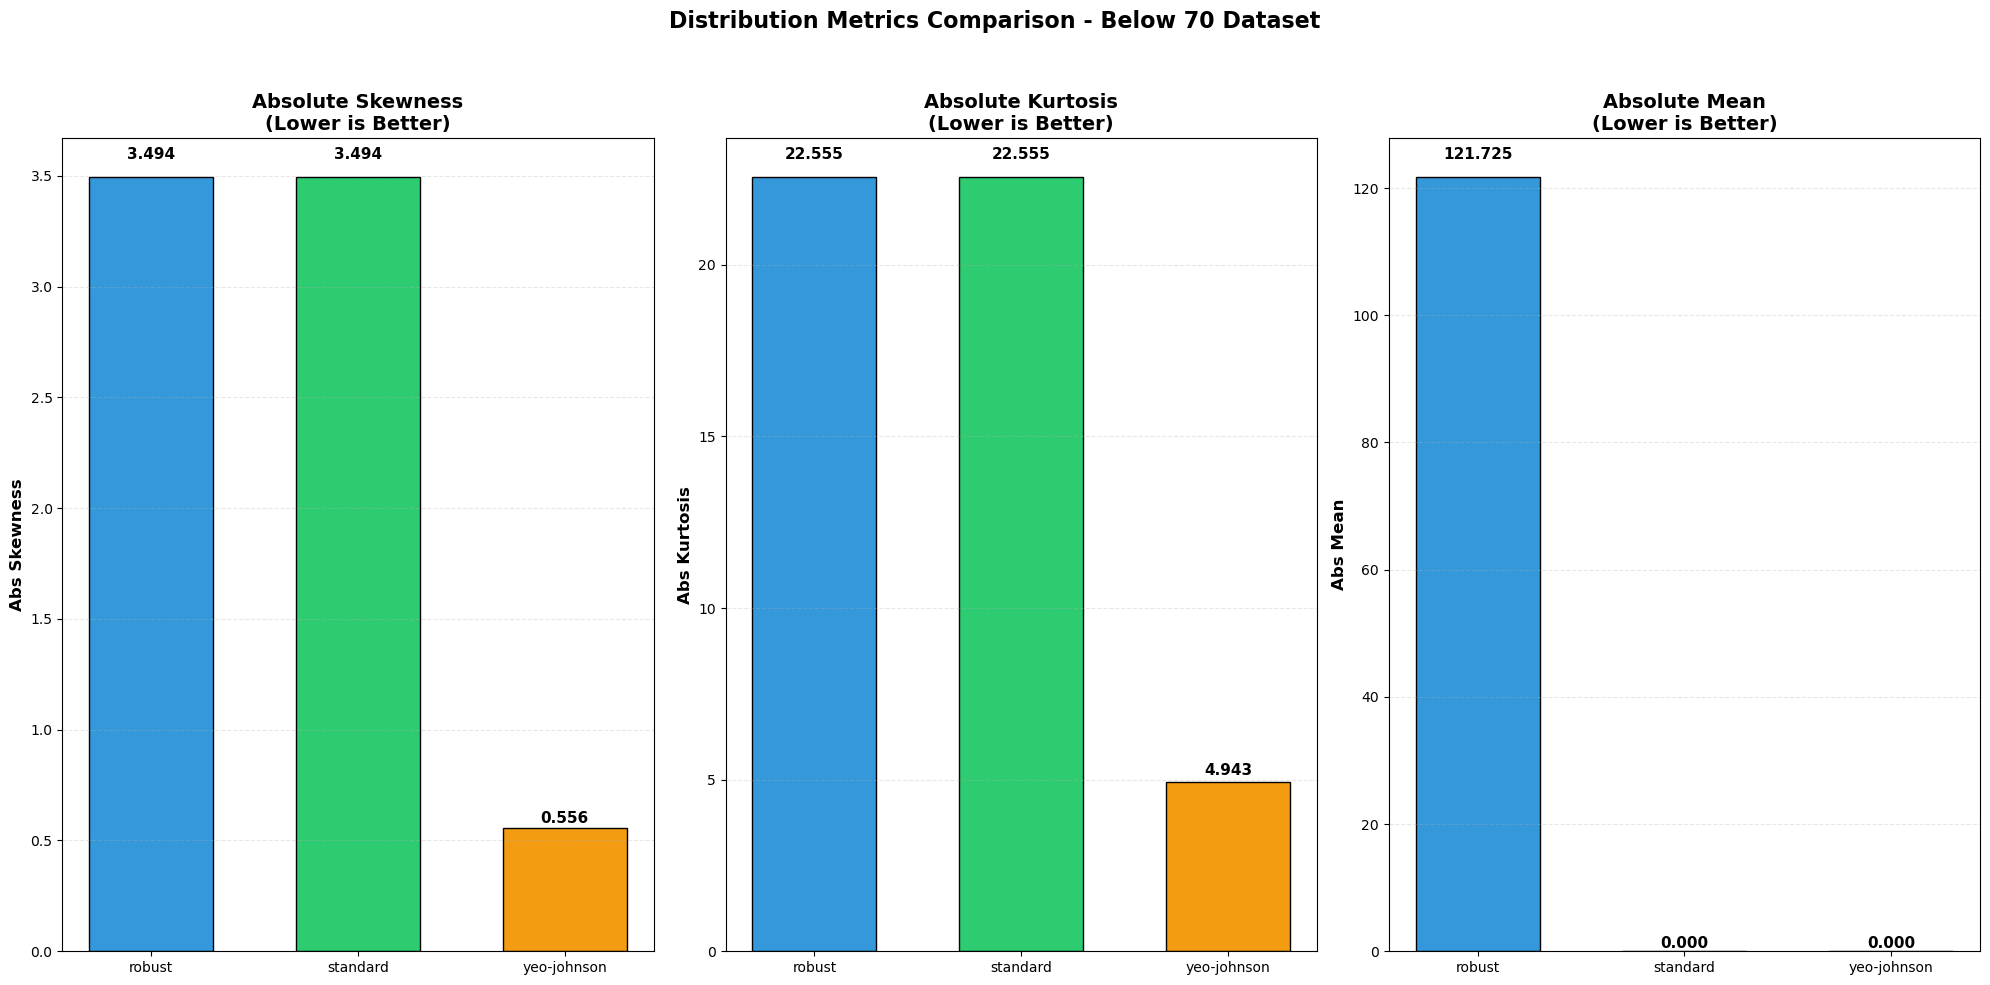

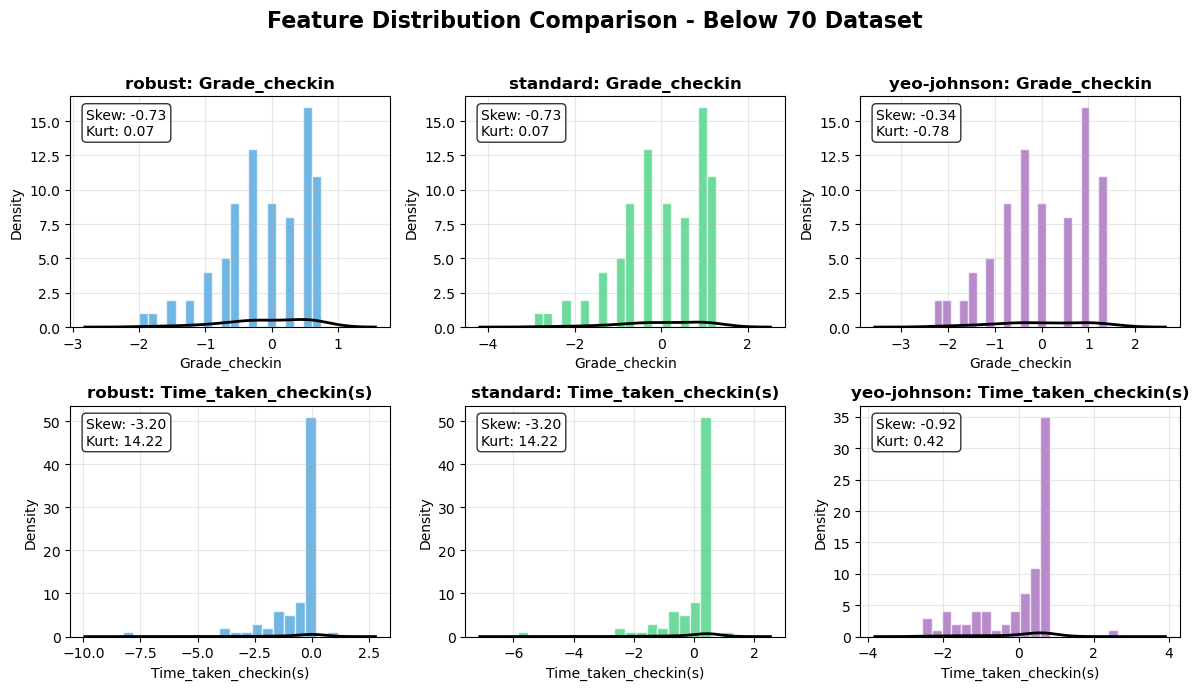


SCALING METHOD COMPARISON FOR Check-in Dataset

Applying robust transformation...

Applying standard transformation...

Applying yeo-johnson transformation...

NUMERICAL COMPARISON OF SCALING METHODS:
        Method  Abs Skewness  Abs Kurtosis  Abs Mean   Std Dev
0       robust        5.8104       58.6455    68.854  932.4966
1     standard        5.8104       58.6455     0.000    1.0027
2  yeo-johnson        0.4627        9.7780     0.000    0.8595

RANKINGS (1 = BEST):
        Method  Skewness Rank  Kurtosis Rank  Mean Rank  Overall Rank
0       robust            2.0            2.0        3.0          2.33
1     standard            3.0            3.0        1.0          2.33
2  yeo-johnson            1.0            1.0        2.0          1.33

Best method by Overall Ranking: yeo-johnson


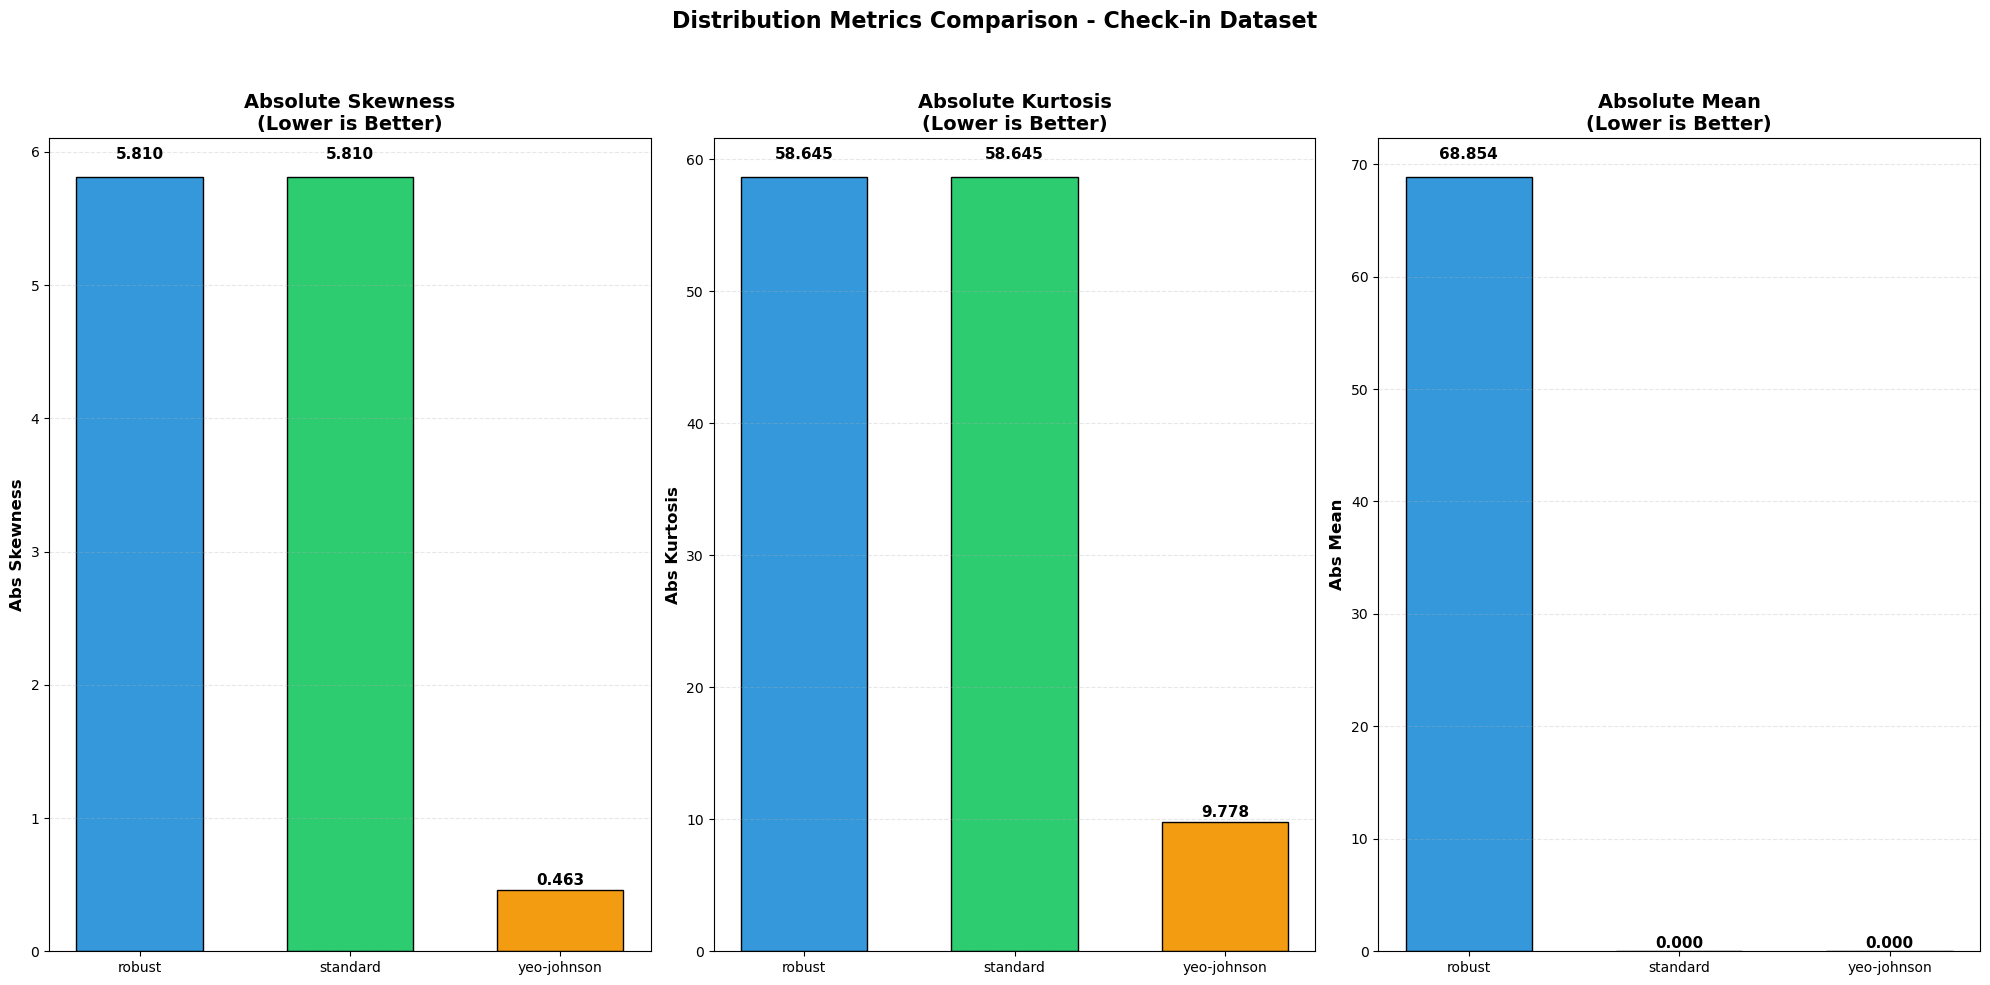

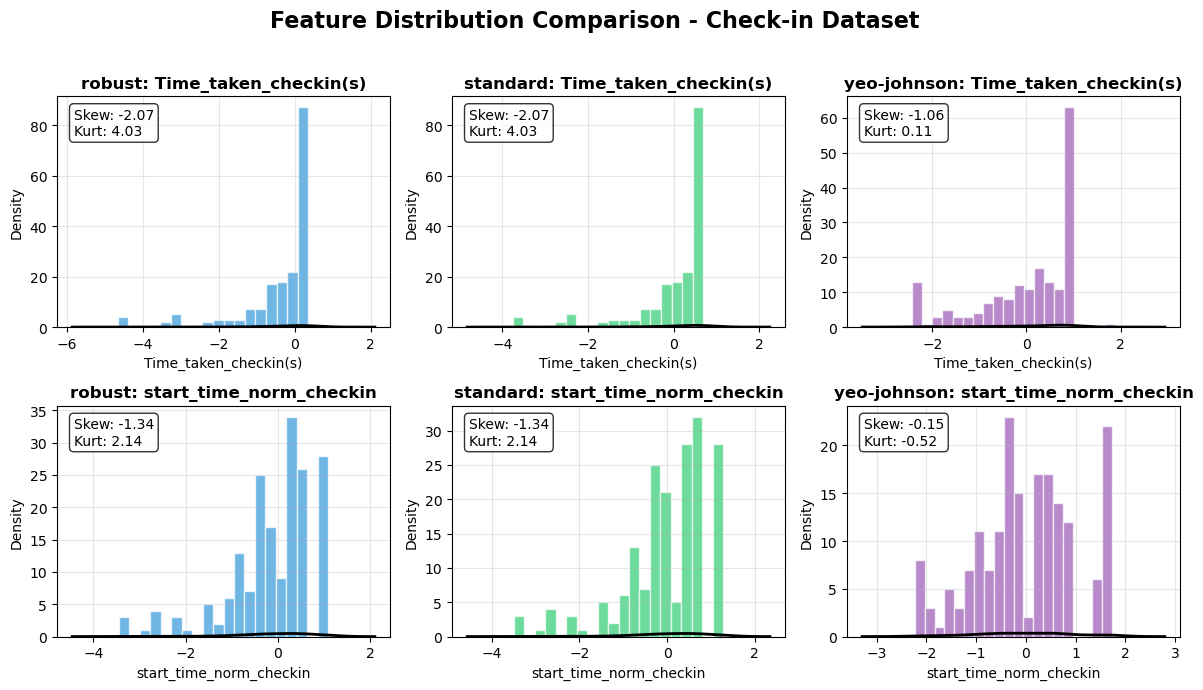


FINAL SCALING METHOD SELECTION
Below 70 Dataset: yeo-johnson
Check-in Dataset: yeo-johnson

Scaling complete. Proceeding to next step...


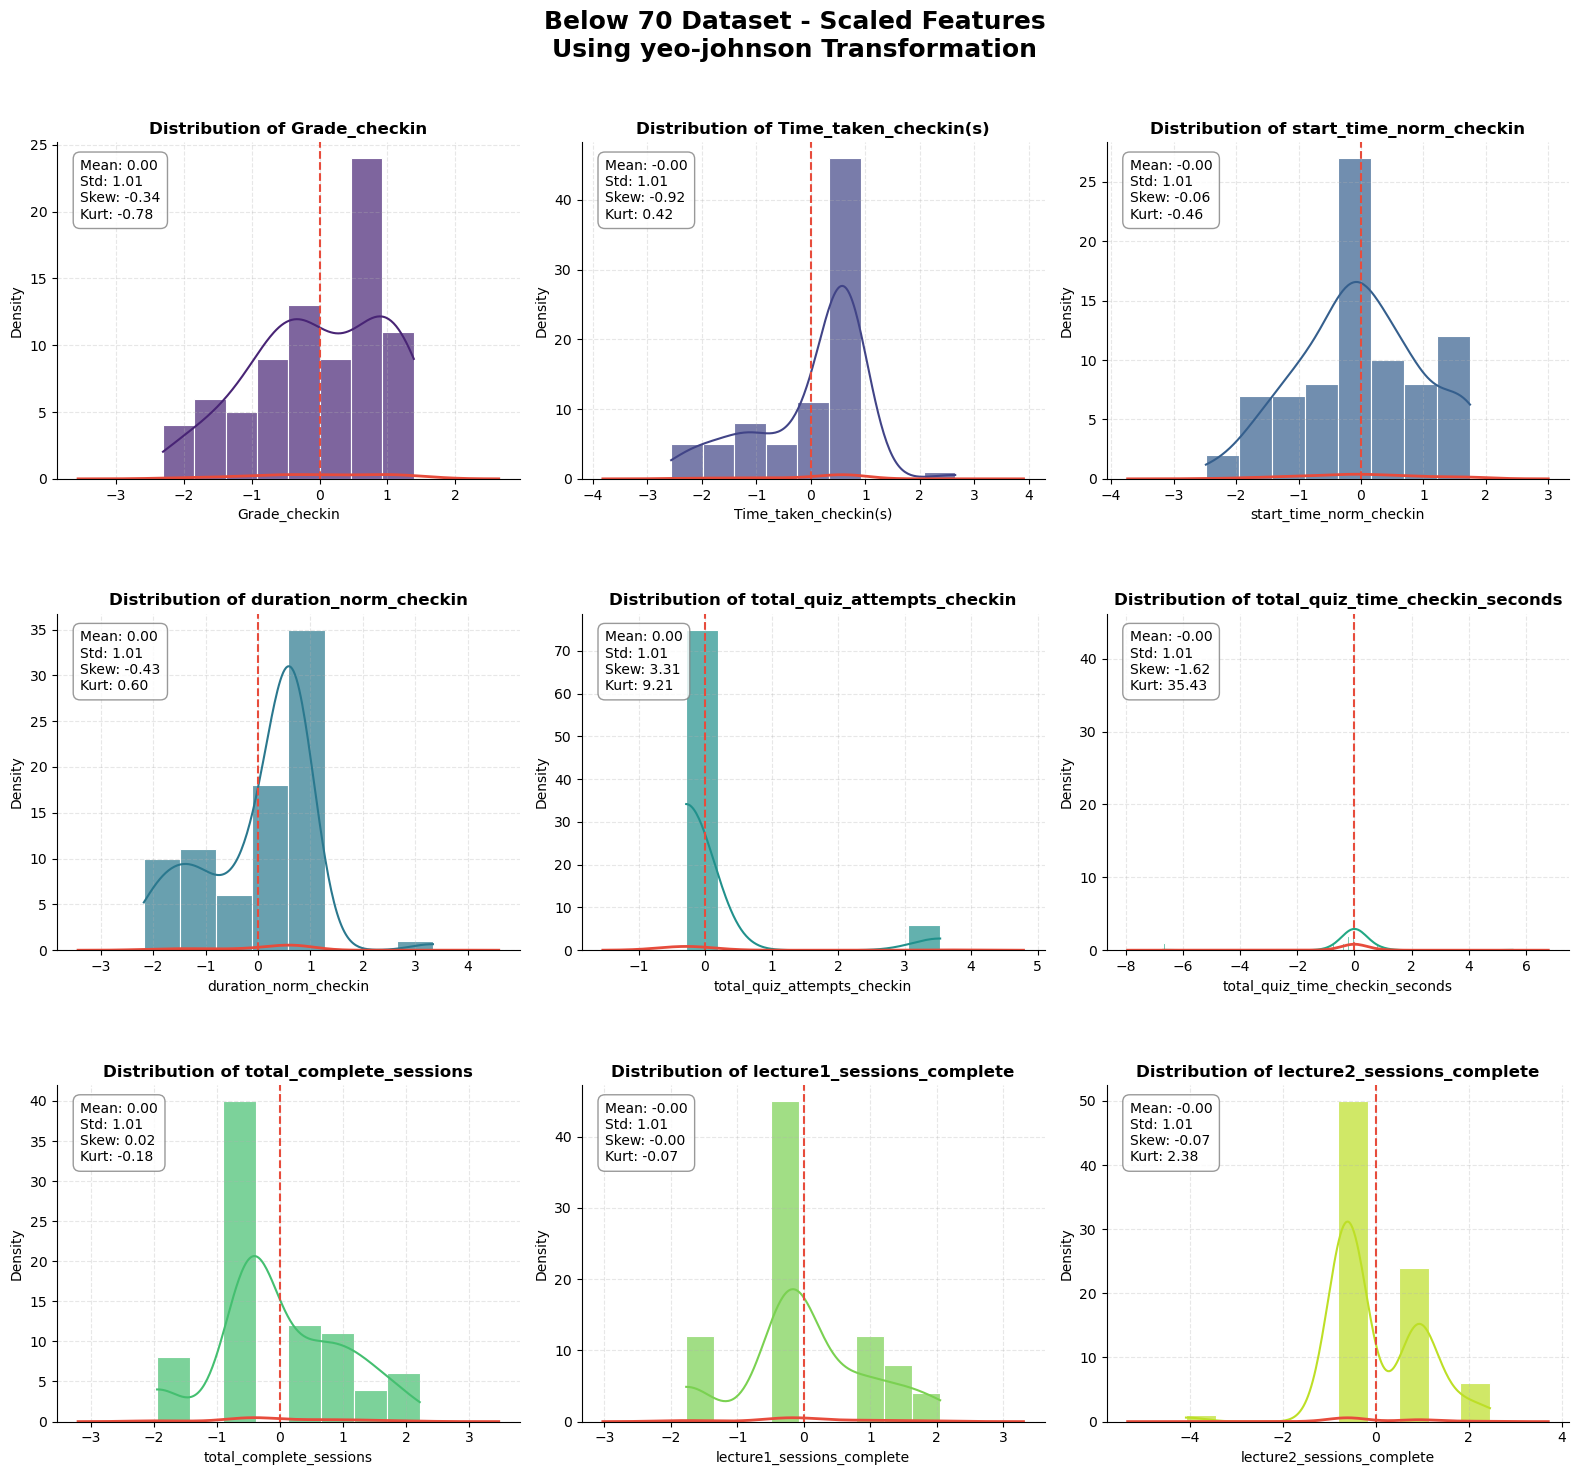

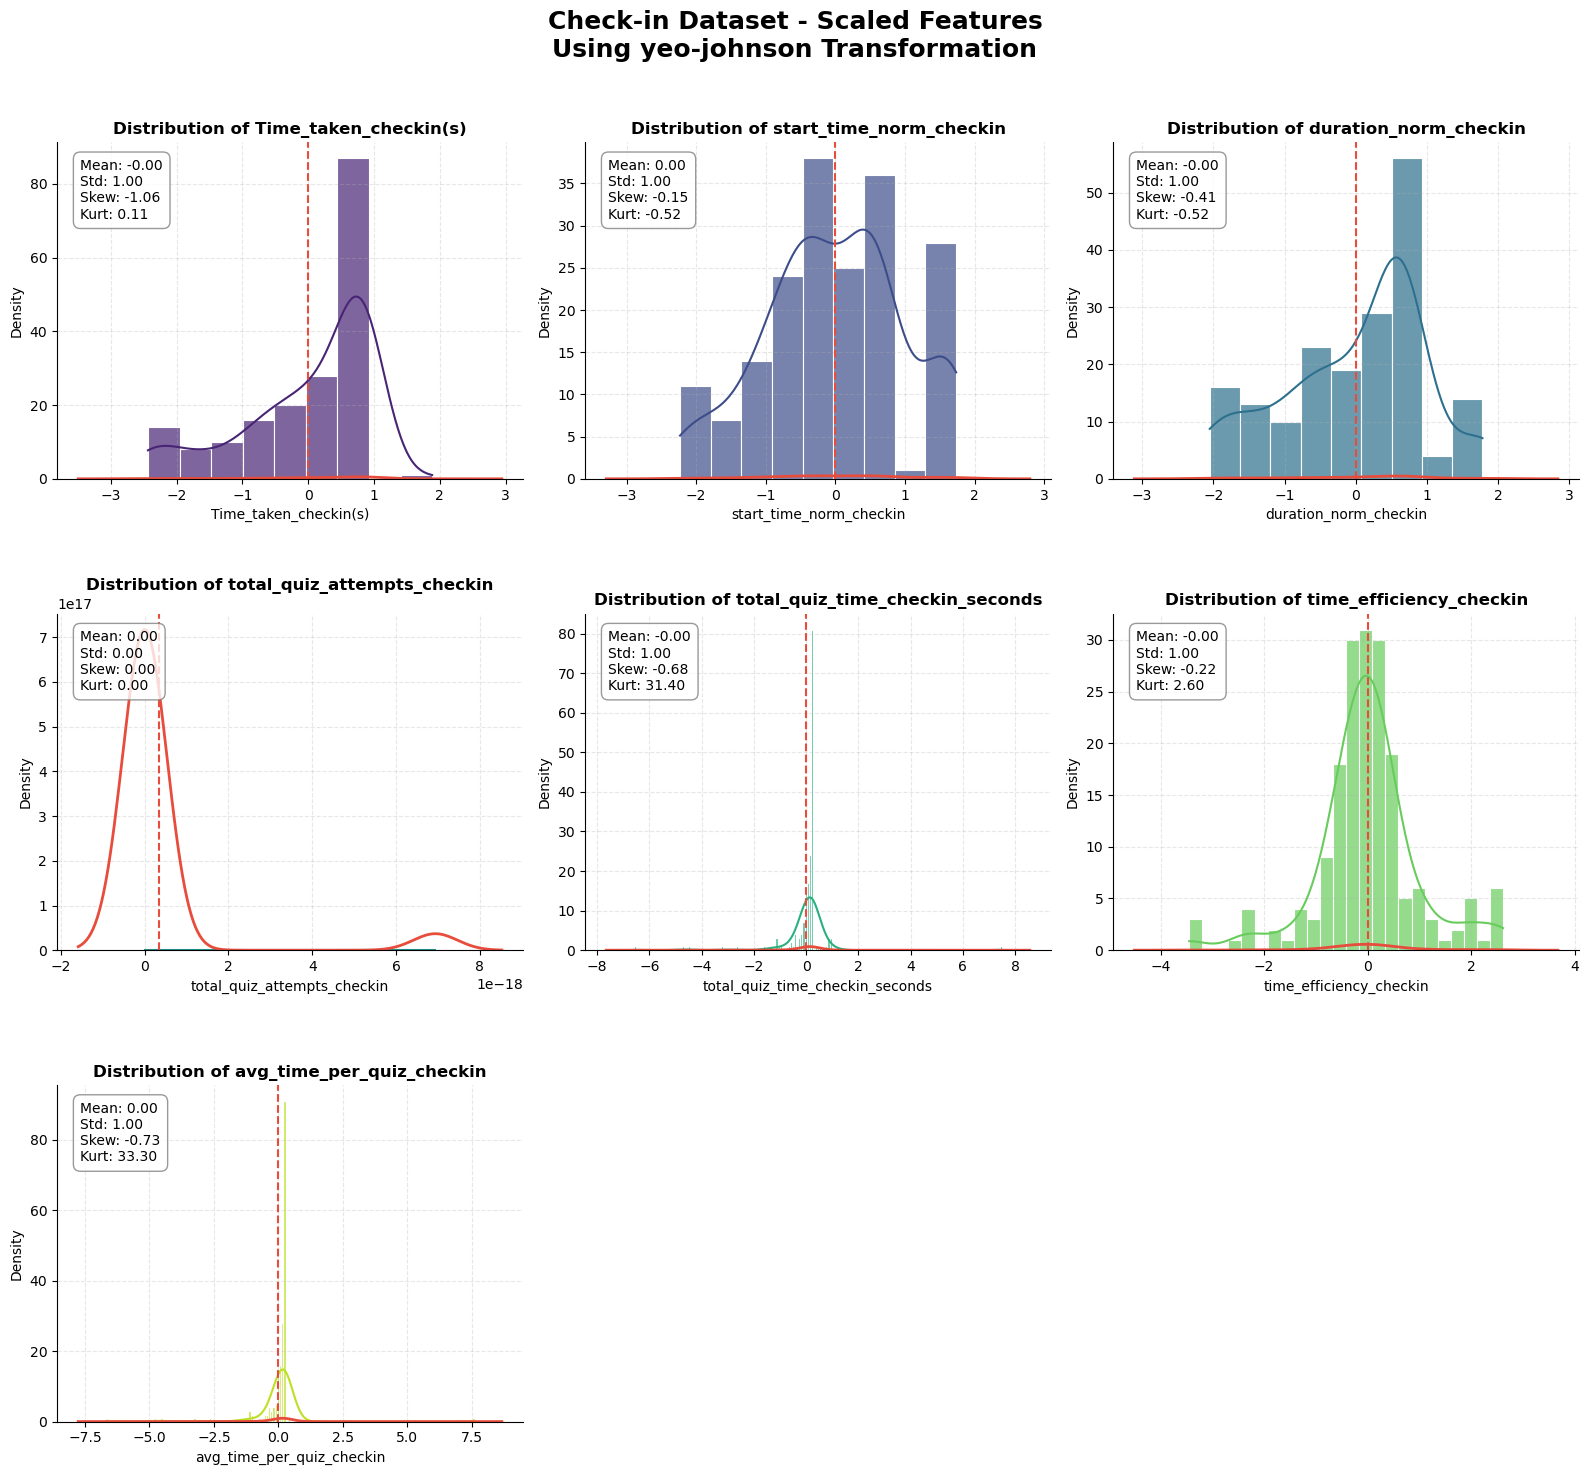

In [6]:
def compare_scaling_methods(X_train, X_test, y_train, dataset_name):
    """
    Compare different scaling methods with cleaner numerical outputs and plots
    
    Methods compared:
    - RobustScaler: Based on median and quantiles (robust to outliers)
    - StandardScaler: Based on mean and standard deviation
    - PowerTransformer (Yeo-Johnson): Makes data more Gaussian-like
    
    Returns: DataFrame comparison and best method based on distribution metrics
    """
    print(f"\n{'='*80}")
    print(f"SCALING METHOD COMPARISON FOR {dataset_name}")
    print(f"{'='*80}")
    
    # Dictionary to store results
    results = {}
    
    # Define the three scaling methods
    scalers = {
        'robust': RobustScaler(),
        'standard': StandardScaler(),
        'yeo-johnson': PowerTransformer(method='yeo-johnson')
    }
    
    # Apply each method and collect metrics
    for name, scaler in scalers.items():
        print(f"\nApplying {name} transformation...")
        
        # Scale the data
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns
        )
        
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns
        )
        
        # Calculate distribution metrics
        skewness = X_train_scaled.skew().abs().mean()
        kurtosis = X_train_scaled.kurtosis().abs().mean()
        mean = X_train_scaled.mean().abs().mean()
        std = X_train_scaled.std().mean()
        
        # Store all results
        results[name] = {
            'X_train_scaled': X_train_scaled,
            'X_test_scaled': X_test_scaled,
            'scaler': scaler,
            'metrics': {
                'abs_mean_skewness': skewness,
                'abs_mean_kurtosis': kurtosis,
                'abs_mean': mean,
                'mean_std': std
            }
        }
    
    # Convert results to DataFrame for easier comparison
    comparison_df = pd.DataFrame({
        'Method': list(results.keys()),
        'Abs Skewness': [results[m]['metrics']['abs_mean_skewness'] for m in results],
        'Abs Kurtosis': [results[m]['metrics']['abs_mean_kurtosis'] for m in results],
        'Abs Mean': [results[m]['metrics']['abs_mean'] for m in results],
        'Std Dev': [results[m]['metrics']['mean_std'] for m in results]
    })
    
    # Create rank columns (1 = best)
    comparison_df['Skewness Rank'] = comparison_df['Abs Skewness'].rank()
    comparison_df['Kurtosis Rank'] = comparison_df['Abs Kurtosis'].rank()
    comparison_df['Mean Rank'] = comparison_df['Abs Mean'].rank()
    
    # Calculate overall rank based on distribution metrics only
    comparison_df['Overall Rank'] = (
        comparison_df['Skewness Rank'] + 
        comparison_df['Kurtosis Rank'] + 
        comparison_df['Mean Rank']
    ) / 3
    
    # Show numerical comparison
    print("\nNUMERICAL COMPARISON OF SCALING METHODS:")
    print(comparison_df[['Method', 'Abs Skewness', 'Abs Kurtosis', 'Abs Mean', 'Std Dev']].round(4))
    
    print("\nRANKINGS (1 = BEST):")
    print(comparison_df[['Method', 'Skewness Rank', 'Kurtosis Rank', 'Mean Rank', 'Overall Rank']].round(2))
    
    # Find best method based on overall rank (lowest is best)
    best_method = comparison_df.loc[comparison_df['Overall Rank'].idxmin(), 'Method']
    
    print(f"\nBest method by Overall Ranking: {best_method}")
    
    # Create plots
    plot_scaling_comparison(comparison_df, results, dataset_name)
    
    # Return results
    return comparison_df, results, best_method

def plot_scaling_comparison(comparison_df, results, dataset_name):
    """
    Create clear, stylish plots comparing the scaling methods without R² score
    """
    # Set style
    plt.style.use('default')
    
    # 1. DISTRIBUTION METRICS COMPARISON PLOT
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    fig.patch.set_facecolor('white')
    
    # Define consistent colors
    colors = ['#3498db', '#2ecc71', '#9b59b6']  # Blue, Green, Purple
    
    # Plot all three metrics
    metrics = ['Abs Skewness', 'Abs Kurtosis', 'Abs Mean']
    titles = [
        'Absolute Skewness\n(Lower is Better)', 
        'Absolute Kurtosis\n(Lower is Better)', 
        'Absolute Mean\n(Lower is Better)'
    ]
    
    # Find the best method based on overall rank
    best_method_idx = comparison_df['Overall Rank'].idxmin()
    best_method = comparison_df.iloc[best_method_idx]['Method']
    
    # Create enhanced colors list with best method highlighted
    for i, metric in enumerate(metrics):
        # Create colors with best method for this metric highlighted
        highlight_colors = colors.copy()
        best_idx = comparison_df[metric].idxmin()
        if best_idx < len(colors):
            highlight_colors[best_idx] = '#f39c12'  # Gold for best method
        
        bars = axes[i].bar(
            comparison_df['Method'],
            comparison_df[metric],
            color=highlight_colors,
            width=0.6,
            edgecolor='black',
            linewidth=1
        )
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            axes[i].text(
                bar.get_x() + bar.get_width()/2,
                height * 1.02,
                f'{height:.3f}',
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=11
            )
        
        axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
        axes[i].grid(axis='y', alpha=0.3, linestyle='--')
        axes[i].set_ylabel(metric, fontsize=12, fontweight='bold')
    
    plt.suptitle(f'Distribution Metrics Comparison - {dataset_name}', 
                fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    
    
    plt.savefig(f'{dataset_name}_distribution_metrics.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # 2. FEATURE DISTRIBUTIONS (SAMPLE)
    methods = comparison_df['Method'].tolist()
    sample_features = results[methods[0]]['X_train_scaled'].columns[:2]  # Just first 2 features
    
    fig, axes = plt.subplots(len(sample_features), len(methods), 
                            figsize=(len(methods)*4, len(sample_features)*3.5))
    fig.patch.set_facecolor('white')
    
    # If only one feature, ensure axes is 2D
    if len(sample_features) == 1:
        axes = np.array([axes])
    
    for i, feature in enumerate(sample_features):
        for j, method in enumerate(methods):
            data = results[method]['X_train_scaled'][feature]
            ax = axes[i, j]
            
            # Create histogram with KDE
            ax.hist(data, bins=20, color=colors[j], alpha=0.7, edgecolor='white')
            
            # Add density curve
            density = sns.kdeplot(data, ax=ax, color='black', linewidth=2)
            
            # Add stats
            skew = data.skew()
            kurt = data.kurtosis()
            
            # Add text box with stats
            stats_text = f"Skew: {skew:.2f}\nKurt: {kurt:.2f}"
            props = dict(boxstyle='round', facecolor='white', alpha=0.8)
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top', bbox=props)
            
            ax.set_title(f"{method}: {feature}", fontsize=12, fontweight='bold')
            ax.grid(alpha=0.3)
    
    plt.suptitle(f'Feature Distribution Comparison - {dataset_name}', 
                fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'{dataset_name}_feature_distributions.png', dpi=100, bbox_inches='tight')
    plt.show()

# Apply the simplified comparison to both datasets

# Below 70 Dataset comparison
below70_comparison_df, below70_results, best_below70_method = compare_scaling_methods(
    X_train_below70, X_test_below70, y_train_below70, "Below 70 Dataset"
)

# Check-in Dataset comparison
checkin_comparison_df, checkin_results, best_checkin_method = compare_scaling_methods(
    X_train_checkin, X_test_checkin, y_train_checkin, "Check-in Dataset"
)

# Set the best scaled datasets for further use in the pipeline
X_train_below70_scaled = below70_results[best_below70_method]['X_train_scaled']
X_test_below70_scaled = below70_results[best_below70_method]['X_test_scaled']
scaler_below70 = below70_results[best_below70_method]['scaler']

X_train_checkin_scaled = checkin_results[best_checkin_method]['X_train_scaled']
X_test_checkin_scaled = checkin_results[best_checkin_method]['X_test_scaled']
scaler_checkin = checkin_results[best_checkin_method]['scaler']

# Print final summary
print("\n" + "="*80)
print("FINAL SCALING METHOD SELECTION")
print("="*80)
print(f"Below 70 Dataset: {best_below70_method}")
print(f"Check-in Dataset: {best_checkin_method}")
print("\nScaling complete. Proceeding to next step...")

# Function to visualize the distributions of selected features
def plot_scaled_feature_distributions(X_scaled, title, method_name, max_cols=3):
    """
    Create enhanced visualization of scaled feature distributions
    """
    # Setup for multi-plot
    features = X_scaled.columns
    n_features = min(9, len(features))  # Limit to first 9 features for clarity
    selected_features = features[:n_features]
    n_cols = min(max_cols, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    # Create figure with clean, white background
    fig = plt.figure(figsize=(16, 5 * n_rows), dpi=100, facecolor='white')
    
    # Generate colors for visual variety
    cmap = plt.cm.viridis
    colors = [cmap(i) for i in np.linspace(0.1, 0.9, n_features)]
    
    for i, (feature, color) in enumerate(zip(selected_features, colors), 1):
        # Create subplot
        ax = plt.subplot(n_rows, n_cols, i)
        
        # Get feature data
        feature_data = X_scaled[feature]
        
        # Create histogram with KDE overlay
        sns.histplot(
            feature_data, 
            kde=True, 
            color=color,
            alpha=0.7,
            edgecolor='white',
            linewidth=0.8,
            ax=ax
        )
        
        # Add KDE curve with contrasting color
        sns.kdeplot(
            feature_data,
            color='#e74c3c',  # red
            linewidth=2,
            ax=ax
        )
        
        # Calculate distribution statistics
        mean = feature_data.mean()
        std = feature_data.std()
        skew = feature_data.skew()
        kurt = feature_data.kurtosis()
        
        # Add vertical line at mean
        ax.axvline(mean, color='#e74c3c', linestyle='--', linewidth=1.5)
        
        # Add statistics box
        stats_text = f"Mean: {mean:.2f}\nStd: {std:.2f}\nSkew: {skew:.2f}\nKurt: {kurt:.2f}"
        props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(
            0.05, 0.95, 
            stats_text, 
            transform=ax.transAxes, 
            fontsize=10, 
            verticalalignment='top', 
            bbox=props
        )
        
        # Enhanced styling
        ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
        ax.set_xlabel(feature, fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Overall title with method information
    plt.suptitle(f'{title}\nUsing {method_name} Transformation', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.4)
    plt.show()

# Plot distributions of scaled features with selected method
plot_scaled_feature_distributions(
    X_train_below70_scaled, 
    "Below 70 Dataset - Scaled Features",
    best_below70_method
)

plot_scaled_feature_distributions(
    X_train_checkin_scaled, 
    "Check-in Dataset - Scaled Features",
    best_checkin_method
)

Step7: Model Selection and Hyperparameter Tuning

In [7]:
def train_and_evaluate_with_tuning(X_train, X_test, y_train, y_test, dataset_name):
    """Train and evaluate models with hyperparameter tuning"""
    
    # Dictionary to store results
    results = {}
    
    # Define model configurations with hyperparameter grids
    model_configs = {
        'Ridge': {
            'model': Ridge(),
            'params': {
                'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
                'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
            }
        },
        'Lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1.0],
                'max_iter': [2000],
                'selection': ['cyclic', 'random']
            }
        },
        'RandomForest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0]
            }
        },
        'SVR': {
            'model': SVR(),
            'params': {
                'kernel': ['linear', 'rbf'],
                'C': [0.1, 1, 10],
                'gamma': ['scale', 'auto']
            }
        }
    }
    
    print(f"\nModel Training and Tuning for {dataset_name}")
    
    # Train and evaluate each model
    for name, config in model_configs.items():
        print(f"\n{'-'*50}")
        print(f"Training {name}...")
        
        # Create GridSearchCV
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=1
        )
        
        # Fit model
        grid_search.fit(X_train, y_train)
        
        # Get best model
        best_model = grid_search.best_estimator_
        
        # Make predictions
        y_pred = best_model.predict(X_test)
        
        # Evaluate
        metrics = evaluate_model(y_test, y_pred, name)
        
        # Store results
        results[name] = {
            'model': best_model,
            'best_params': grid_search.best_params_,
            'metrics': metrics,
            'cv_score': -grid_search.best_score_
        }
        
        # Print feature importance for tree-based models
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': X_train.columns,
                'importance': best_model.feature_importances_
            }).sort_values('importance', ascending=False)
            print(f"\nFeature Importance for {name}:")
            print(feature_importance.head(10))  # Show top 10 features
    
    return results

def evaluate_model(y_true, y_pred, model_name):
    """Evaluate model performance with multiple metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nPerformance Metrics for {model_name}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Train and evaluate models
print("\nStarting model training and evaluation. This may take some time...")

# Train models with hyperparameter tuning for both datasets
below70_results = train_and_evaluate_with_tuning(
    X_train_below70_scaled, X_test_below70_scaled, 
    y_train_below70, y_test_below70, 
    "Below 70 Dataset"
)

checkin_results = train_and_evaluate_with_tuning(
    X_train_checkin_scaled, X_test_checkin_scaled, 
    y_train_checkin, y_test_checkin, 
    "Check-in Dataset"
)


Starting model training and evaluation. This may take some time...

Model Training and Tuning for Below 70 Dataset

--------------------------------------------------
Training Ridge...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag


Performance Metrics for Ridge:
RMSE: 21.2169
MAE: 18.3146
R² Score: 0.5067

--------------------------------------------------
Training Lasso...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Performance Metrics for Lasso:
RMSE: 20.9344
MAE: 17.9057
R² Score: 0.5197

--------------------------------------------------
Training RandomForest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.577e+03, tolerance: 3.952e+00
  model = cd_fast.enet_coordinate_descent(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.028e+03, tolerance: 4.680e+00
  model = cd_fast.enet_coordinate_descent(
/Users/h.g/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap


Performance Metrics for RandomForest:
RMSE: 17.9681
MAE: 14.0513
R² Score: 0.6462

Feature Importance for RandomForest:
                             feature  importance
0                      Grade_checkin    0.197348
13          start_time_norm_checkout    0.182880
16          time_efficiency_checkout    0.144970
2            start_time_norm_checkin    0.072864
12            Time_taken_checkout(s)    0.053875
20            timing_strategy_change    0.051390
14            duration_norm_checkout    0.048774
15           time_efficiency_checkin    0.040793
11  total_quiz_time_checkout_seconds    0.040715
18        avg_time_per_quiz_checkout    0.033753

--------------------------------------------------
Training GradientBoosting...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Performance Metrics for GradientBoosting:
RMSE: 19.8243
MAE: 15.9026
R² Score: 0.5693

Feature Importance for GradientBoosting:
                             feature  importance
0                  

Step8: Model Visualization and Ensemble


STEP 8: MODEL VISUALIZATION, SELECTION AND ENSEMBLE CREATION

Visualizing model comparison results...


/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=rmse_values, ax=axs[0], palette=colors_rmse)
/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mae_values, ax=axs[1], palette=colors_mae)
/var/folders/5y/vmqy4y397_d5hs8

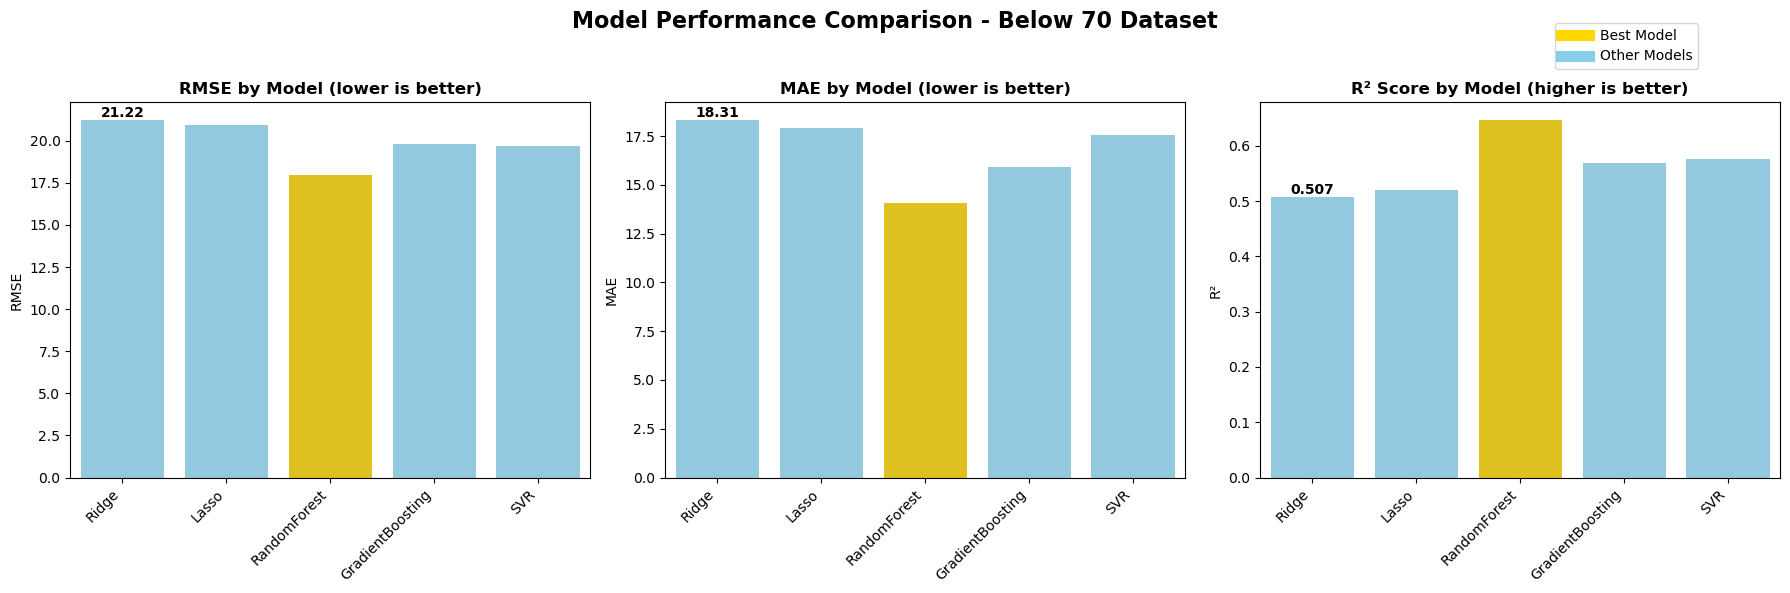

/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=rmse_values, ax=axs[0], palette=colors_rmse)
/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mae_values, ax=axs[1], palette=colors_mae)
/var/folders/5y/vmqy4y397_d5hs8

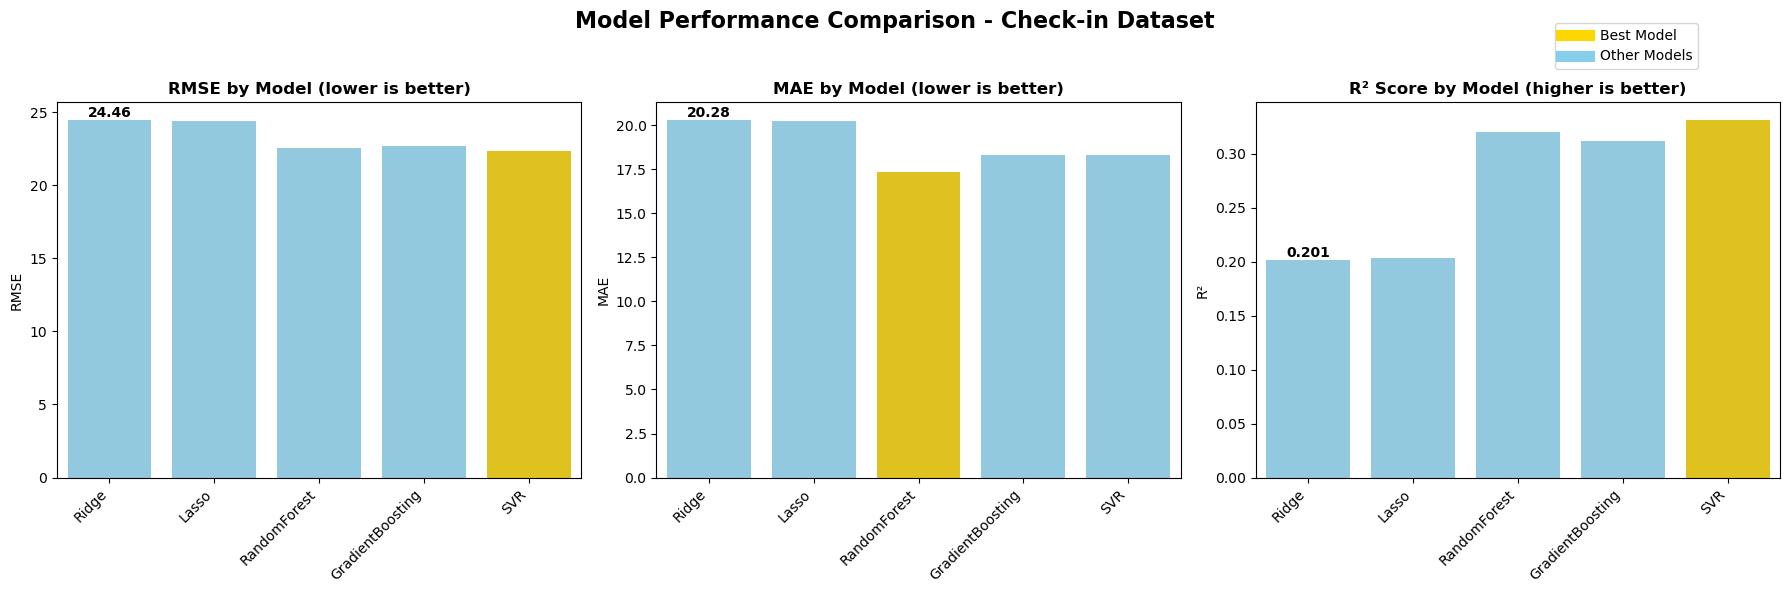

/var/folders/5y/vmqy4y397_d5hs8nmp4c5c8r0000gn/T/ipykernel_36177/2712533752.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')



Analyzing models in detail to select best performers...

Best Model Analysis for Below 70 Dataset

Model Performance Ranking (sorted by R²):
           Model      RMSE       MAE       R²  Avg Rank
    RandomForest 17.968085 14.051308 0.646198  1.000000
             SVR 19.685293 17.564104 0.575341  2.333333
GradientBoosting 19.824272 15.902639 0.569323  2.666667
           Lasso 20.934436 17.905736 0.519737  4.000000
           Ridge 21.216939 18.314553 0.506687  5.000000

Selected Best Model: RandomForest
R² Score: 0.6462
RMSE: 17.9681
MAE: 14.0513

Hyperparameters:
  - max_depth: 10
  - min_samples_leaf: 2
  - min_samples_split: 2
  - n_estimators: 200

Top 10 Important Features:
                         Feature  Importance
                   Grade_checkin    0.197348
        start_time_norm_checkout    0.182880
        time_efficiency_checkout    0.144970
         start_time_norm_checkin    0.072864
          Time_taken_checkout(s)    0.053875
          timing_strategy_change    0.

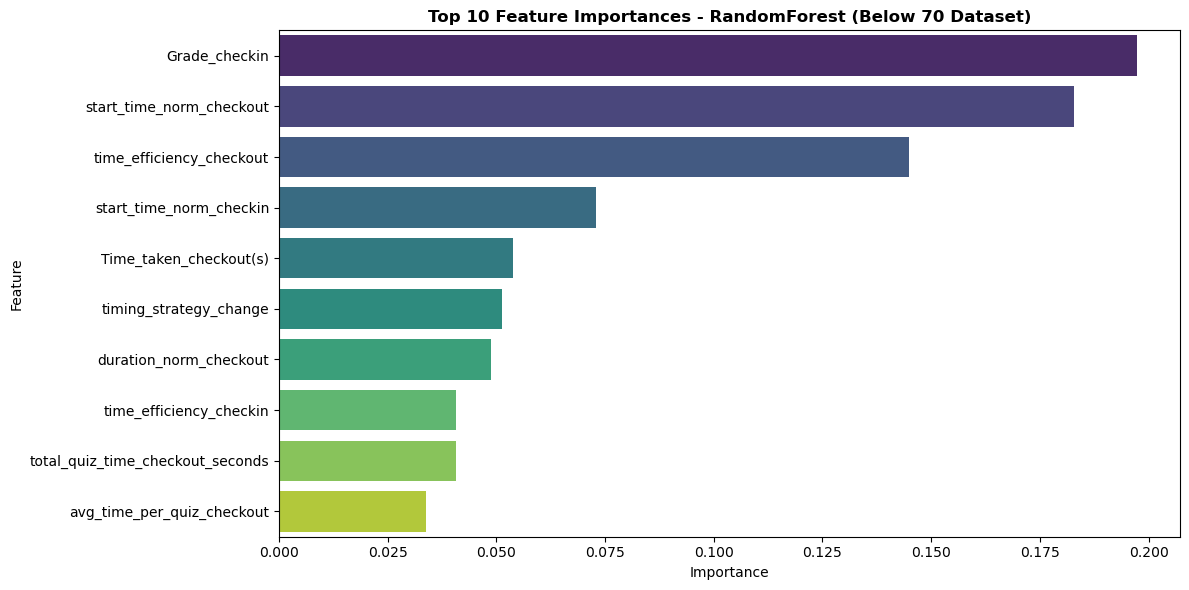


Best Model Analysis for Check-in Dataset

Model Performance Ranking (sorted by R²):
           Model      RMSE       MAE       R²  Avg Rank
             SVR 22.377191 18.313214 0.331295  1.666667
    RandomForest 22.566961 17.342148 0.319905  1.666667
GradientBoosting 22.704078 18.281674 0.311616  2.666667
           Lasso 24.415806 20.234455 0.203904  4.000000
           Ridge 24.456410 20.282033 0.201254  5.000000

Selected Best Model: SVR
R² Score: 0.3313
RMSE: 22.3772
MAE: 18.3132

Hyperparameters:
  - C: 10
  - gamma: scale
  - kernel: rbf


In [8]:
def visualize_model_results(results, dataset_name):
    """
    Visualize model performance comparison with enhanced clarity for best performers
    """
    # Extract metrics
    model_names = list(results.keys())
    rmse_values = [results[model]['metrics']['rmse'] for model in model_names]
    mae_values = [results[model]['metrics']['mae'] for model in model_names]
    r2_values = [results[model]['metrics']['r2'] for model in model_names]
    
    # Identify best models for each metric
    best_rmse_idx = np.argmin(rmse_values)
    best_mae_idx = np.argmin(mae_values)
    best_r2_idx = np.argmax(r2_values)
    
    # Create figure
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    # Custom color palette - normal bars in blue, best model in gold
    colors_rmse = ['skyblue'] * len(model_names)
    colors_rmse[best_rmse_idx] = 'gold'
    
    colors_mae = ['skyblue'] * len(model_names)
    colors_mae[best_mae_idx] = 'gold'
    
    colors_r2 = ['skyblue'] * len(model_names)
    colors_r2[best_r2_idx] = 'gold'
    
    # Plot RMSE with best model highlighted
    sns.barplot(x=model_names, y=rmse_values, ax=axs[0], palette=colors_rmse)
    axs[0].set_title('RMSE by Model (lower is better)', fontweight='bold')
    axs[0].set_ylabel('RMSE')
    axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
    axs[0].bar_label(axs[0].containers[0], fmt='%.2f', fontweight='bold')
    
    # Plot MAE with best model highlighted
    sns.barplot(x=model_names, y=mae_values, ax=axs[1], palette=colors_mae)
    axs[1].set_title('MAE by Model (lower is better)', fontweight='bold')
    axs[1].set_ylabel('MAE')
    axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
    axs[1].bar_label(axs[1].containers[0], fmt='%.2f', fontweight='bold')
    
    # Plot R² with best model highlighted
    sns.barplot(x=model_names, y=r2_values, ax=axs[2], palette=colors_r2)
    axs[2].set_title('R² Score by Model (higher is better)', fontweight='bold')
    axs[2].set_ylabel('R²')
    axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=45, ha='right')
    axs[2].bar_label(axs[2].containers[0], fmt='%.3f', fontweight='bold')
    
    # Set main title
    plt.suptitle(f'Model Performance Comparison - {dataset_name}', fontsize=16, fontweight='bold')
    
    # Add legend for best models
    legend_elements = [
        plt.Line2D([0], [0], color='gold', lw=8, label='Best Model'),
        plt.Line2D([0], [0], color='skyblue', lw=8, label='Other Models')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.95, 0.97))
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # Return best model name based on R² (primary metric)
    return model_names[best_r2_idx]

def analyze_and_select_best_model(results, dataset_name):
    """
    Analyze model results and select the best model based on multiple criteria
    """
    # Create a DataFrame to organize results
    models_df = pd.DataFrame({
        'Model': list(results.keys()),
        'RMSE': [results[model]['metrics']['rmse'] for model in results.keys()],
        'MAE': [results[model]['metrics']['mae'] for model in results.keys()],
        'R²': [results[model]['metrics']['r2'] for model in results.keys()],
        'CV Score (MSE)': [results[model]['cv_score'] for model in results.keys()]
    })
    
    # Add ranking columns (1 = best)
    models_df['RMSE Rank'] = models_df['RMSE'].rank()
    models_df['MAE Rank'] = models_df['MAE'].rank() 
    models_df['R² Rank'] = models_df['R²'].rank(ascending=False)
    
    # Calculate average rank
    models_df['Avg Rank'] = (models_df['RMSE Rank'] + models_df['MAE Rank'] + models_df['R² Rank']) / 3
    
    # Sort by R² (descending) as primary metric
    models_df = models_df.sort_values('R²', ascending=False).reset_index(drop=True)
    
    # Identify best model (highest R²)
    best_model_name = models_df.iloc[0]['Model']
    
    print(f"\n{'='*60}")
    print(f"Best Model Analysis for {dataset_name}")
    print(f"{'='*60}")
    
    # Display sorted model performance table
    print("\nModel Performance Ranking (sorted by R²):")
    print(models_df[['Model', 'RMSE', 'MAE', 'R²', 'Avg Rank']].to_string(index=False))
    
    # Display best model information
    print(f"\n{'='*60}")
    print(f"Selected Best Model: {best_model_name}")
    print(f"{'='*60}")
    print(f"R² Score: {models_df.iloc[0]['R²']:.4f}")
    print(f"RMSE: {models_df.iloc[0]['RMSE']:.4f}")
    print(f"MAE: {models_df.iloc[0]['MAE']:.4f}")
    
    # Show hyperparameters of the best model
    print("\nHyperparameters:")
    for param, value in results[best_model_name]['best_params'].items():
        print(f"  - {param}: {value}")
    
    # Feature importance for tree-based models
    if hasattr(results[best_model_name]['model'], 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'Feature': X_train_below70_scaled.columns if dataset_name == "Below 70 Dataset" else X_train_above70_scaled.columns,
            'Importance': results[best_model_name]['model'].feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("\nTop 10 Important Features:")
        print(feature_importance.head(10).to_string(index=False))
        
        # Visualize feature importance
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
        plt.title(f'Top 10 Feature Importances - {best_model_name} ({dataset_name})', fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return best_model_name, results[best_model_name]['model']



# Main execution for Step 8
print("\n" + "="*80)
print("STEP 8: MODEL VISUALIZATION, SELECTION AND ENSEMBLE CREATION")
print("="*80)

# Visualize model results and get best model name
print("\nVisualizing model comparison results...")
best_below70_model_name = visualize_model_results(below70_results, "Below 70 Dataset")
best_checkin_model_name = visualize_model_results(checkin_results, "Check-in Dataset")

# Perform detailed analysis of models and select best for each dataset
print("\nAnalyzing models in detail to select best performers...")
best_below70_name, best_below70_model = analyze_and_select_best_model(below70_results, "Below 70 Dataset")
best_checkin_name, best_checkin_model = analyze_and_select_best_model(checkin_results, "Check-in Dataset")

